# Libraries

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
# Add benchmarking dir so helpers.plot is importable
_bench = Path.cwd().parents[3]
sys.path.insert(0, str(_bench))
from helpers.plot import (
    plot_grouped_bar_by_columns,
    plot_single_bar_metric,
    plot_rank_comparison,
    plot_multi_rank_comparison,
    render_dlq_analysis,
)


# Evaluating CLOUDBENCH Benchmarks 

Here we will evaluate the raw query metrics returned by Cloudbench. These raw metrics were calculated using [Cloudbench](https://huggingface.co/datasets/sagecontinuum/Cloudbench) with a [CLIP](https://huggingface.co/apple/DFN5B-CLIP-ViT-H-14-378) variation named `DFN5B-CLIP-ViT-H-14-378` trained on a dataset filtered by a [Data Filtering Network (DFN)](https://arxiv.org/abs/2309.17425), [NRP's](https://nrp.ai/documentation/userdocs/ai/llm-managed/#available-models) [gemma-4-31B-it](https://huggingface.co/google/gemma-4-31B-it), and set to **response_limit=25**. This means it will return up to 25 images. This was configured this way to match production deployment.

To better understand the results, each image is matched with a query in the dataset. Although not all matched images are relevant to the query.

This version is **query-only** on the v15 collections (`SKIP_INDEX=true`, **no recaption**). It tested the image search with `DFN5B-CLIP-ViT-H-14-378` and `NRP's gemma-4-31B-it` on **Milvus** (replacing Weaviate), using dual dense indexes plus BM25 and CLIP rerank. It included:

- **gemma-4-31B-it for Caption Generation**: Captions are generated for images using NRP's gemma-4-31B-it model.
- **Dual-index Vector Search**: Image and caption CLIP embeddings are stored as separate Milvus fields (`image_vector`, `caption_vector`) instead of a single fused vector. At query time, dense similarity blends both legs with `clip_alpha` (default 0.7 → 70% image / 30% caption).
- **Keyword Search (BM25)**: Milvus BM25 over `search_text` (captions and related text), replacing Weaviate keyword search.
- **Hybrid Search**: Dense (dual CLIP) + sparse (BM25) retrieval via Milvus `WeightedRanker`, controlled by `query_alpha` (default 0.65 → 65% dense / 35% keyword; effective WeightedRanker **46% image / 20% caption / 35% BM25**). Query method: `clip_hybrid_query_dual_index`.
- **CLIP Reranker (`DFN5B-CLIP-ViT-H-14-378`)**: Replaces the previous Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. The query text is embedded once and scored against stored `image_vector`s (no per-hit image I/O), matching production `logits_per_image`-style ranking.
- **Triton Dynamic Batching**: CLIP (and Gemma when served on Triton) use server-side dynamic batching so concurrent embedding/caption requests are coalesced into larger GPU batches, improving indexing and query throughput versus one-request-per-inference.
- **LLM Image Byte Limiting**: Caption images are preprocessed with `LLM_IMAGE_BYTE_LIMITING=true` before NRP gemma calls: RGB conversion, longest-side cap (`LLM_MAX_IMAGE_SIDE=6144`), and JPEG downscale/quality stepping to stay under `LLM_MAX_IMAGE_BYTES` (12 MiB).
- **Two-caption prompt (`scientific_two_captions_v1`)**: Caption generation uses the shared [`prompts/`](../../../../../prompts/) catalog (`CAPTION_PROMPT_ID=scientific_two_captions_v1`). Gemma returns three fields: `long_caption` (full detail), `short_caption` (one dense visual sentence, ≤55 tokens, no device IDs/timestamps), and 15 `keywords`. The older versions used CAPTION_PROMPT_ID=scientific_detailed_v1 which utilized only long_caption.
- **CLIP text vs BM25 text split**: CLIP's 77-token limit previously truncated the full caption+keywords string (~40% embedded; keywords never reached `caption_vector`). v15 embeds **`short_caption` + `keywords`** for `caption_vector` in a single CLIP pass, while BM25 `search_text` still indexes **`long_caption` + keywords** (no detail lost on the keyword leg).
- **Milvus caption fields**: `long_caption` and `short_caption` are stored as separate VARCHAR fields (replacing a single `caption` column).
- **Query-only (`SKIP_INDEX=true`)**: Reuses the **v15 Milvus collections**. No recaption and no collection drop. v16 only changes hybrid blend weights at query time. The A–H skip-index sweep is archived in `results/v16/v16_qa*`; this notebook plots production pick **H**.

Here were the Hyperparameters used for the image search:


In [2]:
#show config values
df = pd.read_csv('config_values.csv')
df

,Config Variable,Value,Type
0,advanced_query_parameters,"{'query_alpha': 0.65, 'clip_alpha': 0.7, 'enab...",dict
1,caption_model_name,gemma,str
2,caption_model_prompt,role:\nYou are a world-class Scientific Image ...,str
3,cloudbench_dataset,sagecontinuum/CloudBench,str
4,embed_caption,True,bool
5,embed_image,True,bool
6,enable_bm25,True,bool
7,enable_caption_generation,True,bool
8,hnsw_dist_metric,VectorDistances.COSINE,VectorDistances
9,hnsw_dynamicEfMax,500,int


## Query and Image Collection Process

This explanation was grabbed from the [dataset card](https://huggingface.co/datasets/sagecontinuum/Cloudbench) in huggingface so that we can better understand the results in further sections.

### Query Collection

Queries in CloudBench are **natural-language descriptions of clouds and atmospheric conditions**, written to reflect how researchers would search for sky and cloud imagery. They are not manually authored by humans; instead they are **generated by an AI text model (OpenAI, GPT-5-mini) from seed images**.

**Process:**

1. **Seed images** — A fixed number of seed images (controlled by the query-plan hyperparameters) are selected from the candidate image pool.
2. **Query generation** — For each seed, the text API is given the image (and any associated context) and is prompted to produce a natural-language query that someone might use to find that kind of cloud or sky scene. The model is instructed to describe cloud types, coverage, and atmospheric conditions so the queries reflect realistic search intents (e.g., "Daytime 'mackerel sky'—numerous small, patchy mid/high‑level cloudlets (altocumulus/cirrocumulus) forming a textured, cellular field with blue sky gaps").
3. **One query per seed** — Each generated query is assigned a unique `query_id` (e.g. `query_002`, `query_003`) and is then used to retrieve and label candidate images.

The result is a set of **expert-style queries** over cloud and atmospheric imagery that support evaluation of text-to-image retrieval, relevance classification, and robustness to confounders (e.g., sun glare, occlusion, lighting). For full pipeline details and hyperparameters, see the [dataset card](https://huggingface.co/datasets/sagecontinuum/CloudBench) and the `config_values.csv` in the benchmark's `summary/` directory.


### Image Annotation

CloudBench annotates images in two main ways: **vision-based description** of each image, and **relevance labeling** for each query–image pair. Both are automated with AI models (OpenAI APIs), not human annotators.

**1. Vision annotation (per image)**  
Each image is processed with **OpenAI’s vision API (GPT-5-mini)** to produce:

- **Summary** — A short factual description (≤30 words).
- **Categorical facets** — From fixed taxonomies: `viewpoint` (e.g. ground_upward, ground_horizontal, fisheye_sky), `lighting` (e.g. day, night, dusk, bright, overcast_light), `cloud_coverage` (e.g. 0%-25%, 25%-50%, 50%-75%, 75%-100%), `confounder_type` (e.g. none, fog, sun_glare, precipitation), and boolean facets such as `occlusion_present`, `multiple_cloud_types`, `horizon_visible`, `ground_visible`, `sun_visible`, `precipitation_visible`, `overcast`, `multiple_layers`, `storm_visible`.
- **Controlled vocabulary tags** — Typically 12–18 tags per image (e.g. cirrocumulus_clouds, scattered_clouds, blue_sky, patchy_clouds, sky_dominates).
- **Confidence scores** — For each categorical facet, a score between 0 and 1.

**2. Relevance labeling (per query–image pair)**  
For each query, candidate images are scored as **relevant (1)** or **not relevant (0)** by an **AI judge** using OpenAI’s text API (GPT-5-mini), prompted to reflect whether the image matches the cloud/atmospheric description in the query. This yields the binary `relevance_label` used for retrieval metrics.

**3. CLIPScore (per query–image pair)**  
A **CLIP similarity score** between the query text and the image is computed offline using the model `apple/DFN5B-CLIP-ViT-H-14-378` and stored in the dataset as `clip_score`.

For annotation prompts and hyperparameters (e.g. `VISION_ANNOTATION_*`, `JUDGE_*`), see the [dataset card](https://huggingface.co/datasets/sagecontinuum/CloudBench) and the benchmark’s `summary/config_values.csv`.


### Query Categories

CloudBench does not assign each query to a single category. Instead, **queries are characterized by the same metadata dimensions used for images**, so that retrieval can be analyzed (and evaluated) along cloud- and atmospheric-science-relevant axes. Each query–image pair has metadata from these **locked taxonomies** (defined in the dataset creation config):

- **viewpoint** — How the scene was captured (e.g. `ground_upward`, `ground_horizontal`, `fisheye_sky`).
- **lighting** — Conditions (e.g. `day`, `night`, `dusk`, `bright`, `overcast_light`).
- **cloud_coverage** — Fraction of sky covered by clouds (e.g. `0%-25%`, `25%-50%`, `50%-75%`, `75%-100%`).
- **confounder_type** — Confounders that can cause false positives (e.g. `none`, `fog`, `sun_glare`, `precipitation`).
- **occlusion_present**, **multiple_cloud_types**, **horizon_visible**, **ground_visible**, **sun_visible**, **precipitation_visible**, **overcast**, **multiple_layers**, **storm_visible** — Boolean facets per image.

Queries therefore span **clear/baseline conditions** (e.g. scattered clouds, blue sky), **distinct cloud types** (e.g. altocumulus, cirrus, cumulus), and **confounder-heavy conditions** (sun glare, occlusion, overcast), so the benchmark can measure both recall of relevant cloud imagery and robustness against false positives. For the exact taxonomy values, see the [dataset card](https://huggingface.co/datasets/sagecontinuum/CloudBench) and the benchmark's `summary/config_values.csv`.

### Data Split
The dataset only has a train split. Users can split the dataset as they see fit.

## Query Coverage

Queries cover a range of topics and taxonomies:

![Image Sample](https://huggingface.co/datasets/sagecontinuum/CloudBench/resolve/main/summary/random_image_sample.png)
![Query Coverage](https://huggingface.co/datasets/sagecontinuum/CloudBench/resolve/main/summary/image_proportion_donuts.png)

## Exploratory Data Analysis

The dataset provides an EDA of the data. If you are interested in finding out more analytical information about the data, please refer to it.

[Cloudbench EDA](https://huggingface.co/datasets/sagecontinuum/CloudBench/blob/main/summary/CloudBench_eda_analysis.ipynb)
>NOTE: The EDA can be used along side these evaluation metrics to better understand the results.

## Query Metric Dataset

Each row in the dataframe is evaluating a query used in our image search system:
- **query_id**: an ID given to each unique query in the dataset
- **query**: The query inserted into our image search. These are the same queries from the CloudBench dataset.
- **total_images**: The total images returned from our image search using the specified query.
- **correctly_returned**: The number of images returned that matched with the query indicated in the dataset. For example, if the query was "apple" for the image in the dataset and I used the query "apple" in our image search system. The image returned would be marked as correctly returned since the queries matched.
- **incorrectly_returned**: The number of images returned that did NOT match with the query in the dataset. Using the example above, if we used the query "banana" in our image search system and the image retured had a query of "apple" in the dataset then this will be marked as incorreclt returned.
- **relevant_images**: The number of images returned marked as relevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **non_relevant_images**: The number of images returned marked as nonrelevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **accuracy**: The number of images correctly returned compared to the total images.
- **precision**: The number of relevant images returned compared to the total images.
- **recall**: The number of relevant images returned compared to the number of relevant images in the dataset.
- **hit**: 1 if atleast one relevant image was returned. Take the average of this metric to get the hit rate which is the percentage of queries that had at least one relevant image returned in the top k images (k = response limit).
- **NDCG**: A metric used to evaluate a rerank model. A higher score means relevant images were given a higher score than nonrelevant images.
- **clip_NDCG**: NDCG was also calculated for the clip scores given in the dataset. This column can be used as a comparison to the column NDCG. CLIP DFN5B-CLIP-ViT-H-14-378 was used to provide a rerank score for each image. If NDCG is higher than this column, that means our image search system is doing better.
- **rr**: The reciprocal rank of the rerank scores given in the dataset. Take the average of this metric to get the mean reciprocal rank. This column can be used as a comparison to the column clip_rr.
- **clip_rr**: The reciprocal rank of the clip scores given in the dataset. Take the average of this metric to get the mean reciprocal rank. This column can be used as a comparison to the column rr. CLIP DFN5B-CLIP-ViT-H-14-378 was used to provide a rerank score for each image. If rr is higher than this column, that means our image search system is doing better.
- **diversity**: The diversity of the returned images. Measures how diverse (non-redundant) the top-k list is based on the cosine similarity of the retrieved item vectors. ILS (Intra-List Similarity) is the average pairwise cosine similarity of the retrieved item vectors; diversity = 1 − ILS, so a higher diversity score is more diverse.
- **cloud_coverage**: The cloud coverage of the original image the query was generated from.
- **viewpoint**: The viewpoint of the original image the query was generated from.
- **lighting**: The lighting of the original image the query was generated from.
- **confounder_type**: The confounder type of the original image the query was generated from.
- **occlusion_present**: Whether the original image the query was generated from has occlusion.
- **multiple_cloud_types**: Whether the original image the query was generated from has multiple cloud types.
- **horizon_visible**: Whether the original image the query was generated from has a horizon.
- **ground_visible**: Whether the original image the query was generated from has a ground.
- **sun_visible**: Whether the original image the query was generated from has a sun.
- **precipitation_visible**: Whether the original image the query was generated from has precipitation.
- **overcast**: Whether the original image the query was generated from has overcast.
- **multiple_layers**: Whether the original image the query was generated from has multiple layers.
- **storm_visible**: Whether the original image the query was generated from has a storm.

In [3]:
#load in metric data
df = pd.read_csv('query_eval_metrics.csv')

#rename ndcg and reciprocal rank columns
df = df.rename(columns={
    'rerank_score_NDCG': 'NDCG',
    'clip_score_NDCG': 'clip_NDCG',
    'rerank_score_reciprocal_rank': 'rr',
    'clip_score_reciprocal_rank': 'clip_rr'
})
df

,query_id,query,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,...,confounder_type,occlusion_present,multiple_cloud_types,horizon_visible,ground_visible,sun_visible,precipitation_visible,overcast,multiple_layers,storm_visible
0,query_009,Images of uniform gray overcast stratus/altost...,25,0,25,0,25,0.00,0.00,0.000000,...,none,False,False,False,False,False,False,True,False,False
1,query_003,"Lenticular / wave clouds — smooth, lens-shaped...",25,1,24,1,24,0.04,0.04,0.500000,...,none,False,False,True,True,False,False,False,False,False
2,query_008,Dusk/sunset sky with layered mid- to high-leve...,25,1,24,1,24,0.04,0.04,0.200000,...,none,False,True,True,True,False,False,False,True,False
3,query_006,Images of scattered puffy low-level cumulus cl...,25,1,24,1,24,0.04,0.04,0.142857,...,none,False,False,False,False,False,False,False,False,False
4,query_007,Layered low-to-mid altitude altostratus/stratu...,25,0,25,0,25,0.00,0.00,0.000000,...,none,False,True,True,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,query_115,All-sky fisheye nighttime images with nearly u...,25,1,24,0,25,0.04,0.00,0.000000,...,none,False,False,True,True,False,False,True,False,False
111,query_116,All-sky fisheye images showing a uniform low-a...,25,0,25,0,25,0.00,0.00,0.000000,...,none,False,False,False,True,False,False,False,False,False
112,query_120,Mostly clear blue skies with sparse high‑altit...,25,0,25,0,25,0.00,0.00,0.000000,...,none,False,True,True,True,False,False,False,False,False
113,query_118,Nighttime all-sky (fisheye) images showing thi...,25,0,25,0,25,0.00,0.00,0.000000,...,none,False,False,False,True,False,False,False,False,False


## Indexing DLQ Summary

First, we will look at the DLQ to get an understanding of failed items.

During indexing, failed items are held in a dead-letter queue (`dlq_records.csv`), retried with exponential backoff, then recorded with a terminal status.

CSV columns: `image_id`, `query_id`, `reason`, `error`, `attempts`, `final_status`, `last_error`.

| `final_status` | Meaning |
|----------------|---------|
| `retried_ok` | A later retry succeeded with a real LLM caption |
| `inserted_degraded` | Soft caption failure exhausted retries; item was **force-inserted** using the dataset `summary` as caption backup (or `""` if none) |
| `abandoned` | Hard failure (or force-insert failed); item was **not** indexed |

`reason` is typically `caption_failed` (empty LLM caption) or `hard_fail` (CLIP / processing errors). Use the tables below to see how often fallback was used versus full abandon.

In [4]:
render_dlq_analysis(Path("."))

DLQ rows: 0  |  unique image_ids: 0 | unique query_ids: 0
Nothing to summarize.


## Overall Metrics
Now, we will begin with evaluating all queries.

In [5]:
#calculate the average/sum of each metric
total_images = df['total_images'].sum()
correctly_returned = df['correctly_returned'].sum()
incorrectly_returned = df['incorrectly_returned'].sum()
relevant_images = df['relevant_images'].sum()
non_relevant_images = df['non_relevant_images'].sum()
accuracy = df['accuracy'].mean()
precision = df['precision'].mean()
recall = df['recall'].mean()
hit_rate = df['hit'].mean()
ndcg = df['NDCG'].mean()
clip_ndcg = df['clip_NDCG'].mean()
mrr = df['rr'].mean()
clip_mrr = df['clip_rr'].mean()
diversity = df['diversity'].mean()

# Summary of key metrics
overall_metrics = {
    'total_images': total_images,
    'correctly_returned': correctly_returned,
    'incorrectly_returned': incorrectly_returned,
    'relevant_images': relevant_images,
    'non_relevant_images': non_relevant_images,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'hit_rate': hit_rate,
    'NDCG': ndcg,
    'clip_NDCG': clip_ndcg,
    'mrr': mrr,
    'clip_mrr': clip_mrr,
    'diversity': diversity
}

# Print the summary
for key, value in overall_metrics.items():
    print(f"{key}: {value}")

# Insights
print("\nInsights:")
print(f"The system returned a total of {correctly_returned} correct images out of {total_images} total images returned.")
print(f"The accuracy of the system is {accuracy:.4f}, indicating that {accuracy*100:.2f}% of the returned images correctly matched with the query.")
print(f"The precision of the system is {precision:.4f}, indicating that {precision*100:.2f}% of the total images returned were relevant images.")
print(f"The recall of the system is {recall:.4f}, indicating that {recall*100:.2f}% of the total relevant images in the dataset were returned.")
print(f"The hit rate of the system is {hit_rate:.4f}, indicating that {hit_rate*100:.2f}% of the total queries processed had at least one relevant image.")
print(f"The NDCG score is {ndcg:.4f}, and the Clip NDCG score is {clip_ndcg:.4f}, indicating the ranking quality of the returned images against the CLIP DFN5B-CLIP-ViT-H-14-378 model.")
print(f"The MRR score is {mrr:.4f}, and the Clip MRR score is {clip_mrr:.4f}, indicating how early the first relevant result appears.")
print(f"The diversity of the system is {diversity:.4f} (on a 0–1 scale), indicating the \"spread\" of the returned images. A lower score means the results are more redundant (i.e., highly similar to each other), while a higher score indicates more varied results.")

total_images: 2875
correctly_returned: 37
incorrectly_returned: 2838
relevant_images: 32
non_relevant_images: 2843
accuracy: 0.012869565217391306
precision: 0.011130434782608696
recall: 0.05121797994560142
hit_rate: 0.24347826086956523
NDCG: 0.09533319188566079
clip_NDCG: 0.16089919187109622
mrr: 0.055412259725892546
clip_mrr: 0.1343823326432022
diversity: 0.2455555022240012

Insights:
The system returned a total of 37 correct images out of 2875 total images returned.
The accuracy of the system is 0.0129, indicating that 1.29% of the returned images correctly matched with the query.
The precision of the system is 0.0111, indicating that 1.11% of the total images returned were relevant images.
The recall of the system is 0.0512, indicating that 5.12% of the total relevant images in the dataset were returned.
The hit rate of the system is 0.2435, indicating that 24.35% of the total queries processed had at least one relevant image.
The NDCG score is 0.0953, and the Clip NDCG score is 0.1

## Metrics based on Cloud Coverage

Now, we will evaluate queries based on their cloud coverage.


In [6]:
# Group
coverage_metrics = df.groupby('cloud_coverage').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
coverage_metrics = coverage_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = coverage_metrics
x_column = 'cloud_coverage'
title = 'Cloud Coverage'

metrics

,cloud_coverage,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,0%-25%,325,3,322,1,324,0.009231,0.003077,0.038462,0.076923,0.019946,0.076923,0.005917,0.076923,0.212427
1,25%-50%,850,14,836,13,837,0.016471,0.015294,0.074002,0.352941,0.127464,0.236102,0.072477,0.198121,0.256855
2,50%-75%,800,14,786,14,786,0.017500,0.017500,0.066158,0.343750,0.145360,0.215319,0.082933,0.172173,0.234186
3,75%-100%,875,6,869,4,871,0.006857,0.004571,0.021627,0.114286,0.049106,0.073877,0.033640,0.063095,0.257325
4,unknown,25,0,25,0,25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.243914


### Accuracy

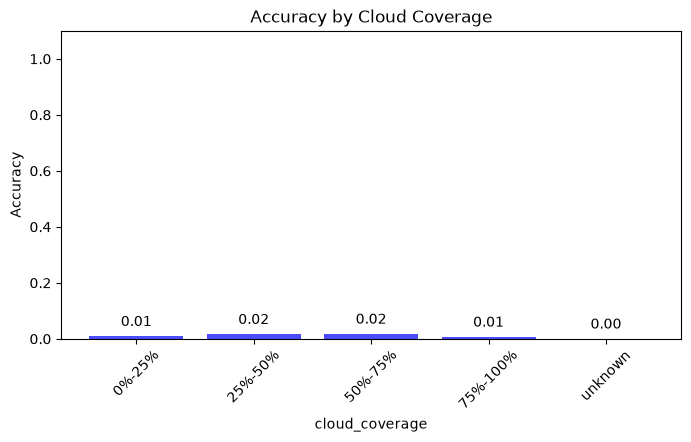

In [7]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

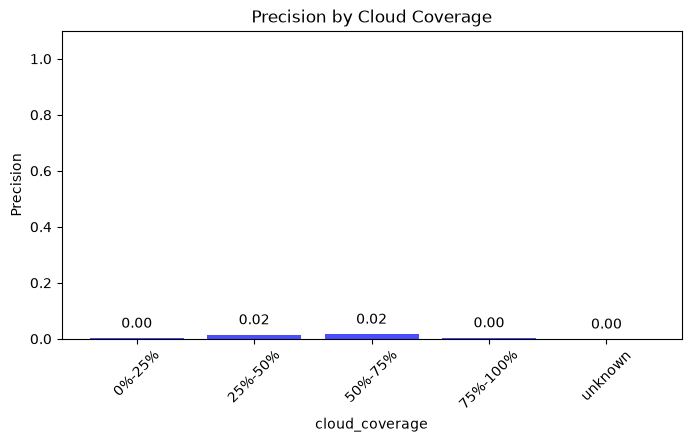

In [8]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

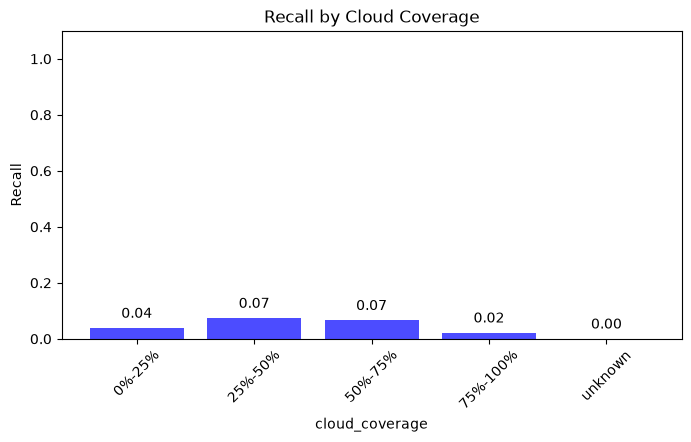

In [9]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

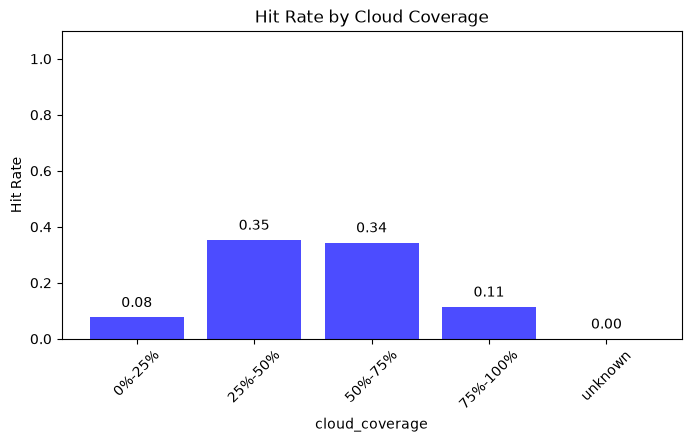

In [10]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

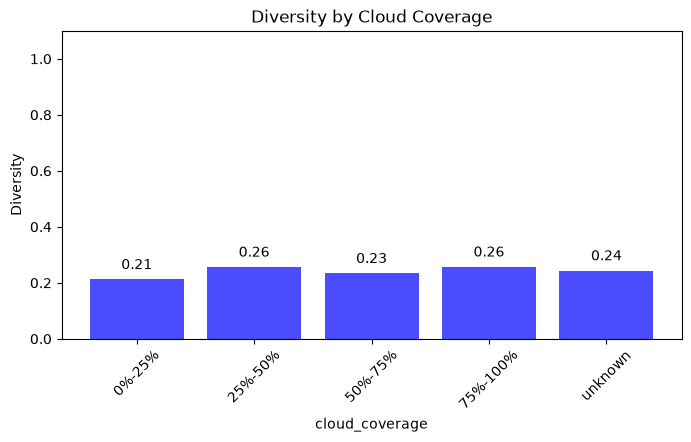

In [11]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

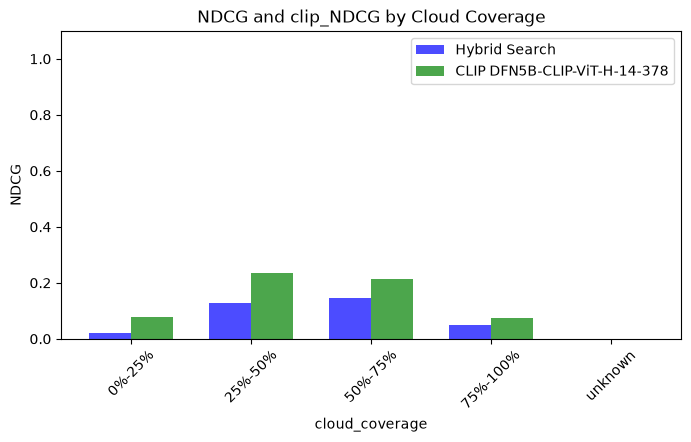

In [12]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

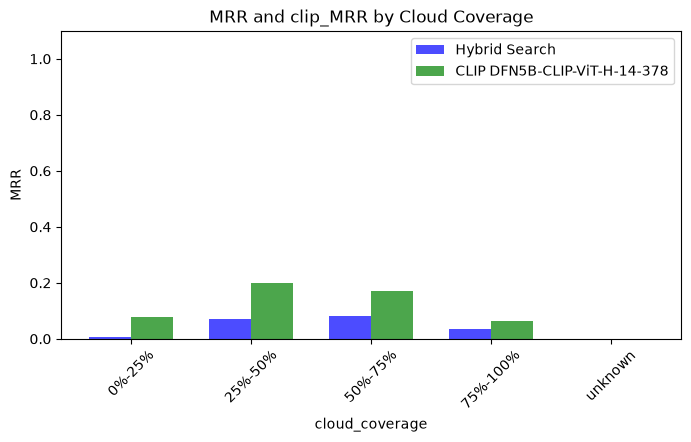

In [13]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Viewpoint

In [14]:
# Group
view_metrics = df.groupby('viewpoint').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
view_metrics = view_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = view_metrics
x_column = 'viewpoint'
title = 'Viewpoint'

metrics

,viewpoint,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,fisheye_sky,975,10,965,6,969,0.010256,0.006154,0.025102,0.153846,0.041217,0.059125,0.013200,0.031227,0.247607
1,ground_horizontal,1175,17,1158,16,1159,0.014468,0.013617,0.080910,0.276596,0.130968,0.221286,0.089311,0.202128,0.249816
2,ground_upward,675,9,666,9,666,0.013333,0.013333,0.033642,0.296296,0.108929,0.177669,0.058836,0.138374,0.237428
3,oblique,25,1,24,1,24,0.040000,0.040000,0.200000,1.000000,0.259304,1.000000,0.071429,1.000000,0.304165
4,other,25,0,25,0,25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.126120


### Accuracy

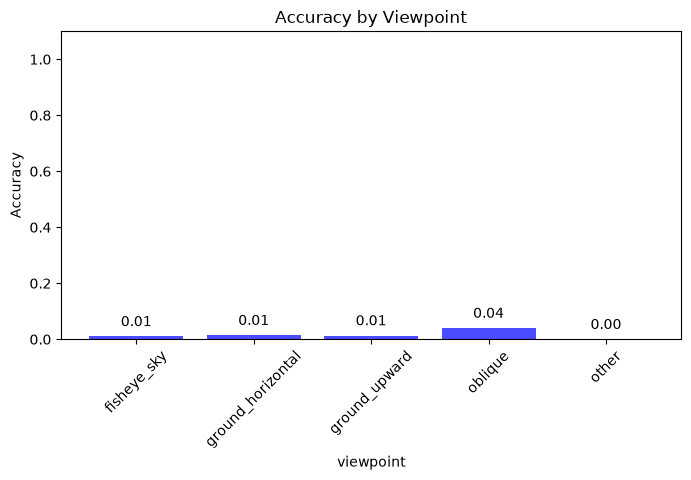

In [15]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

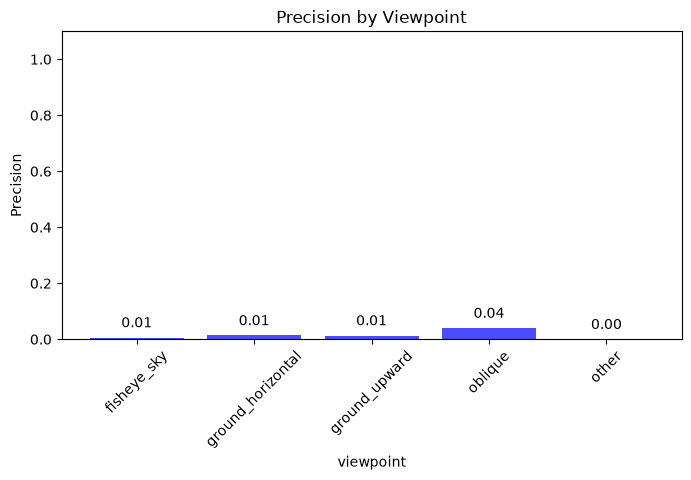

In [16]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

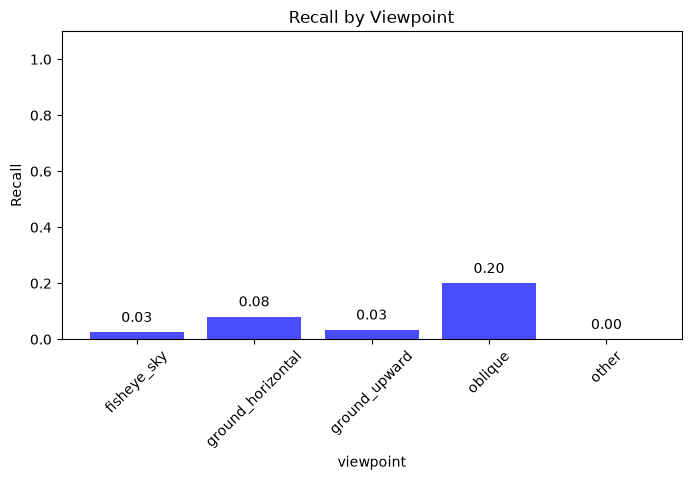

In [17]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

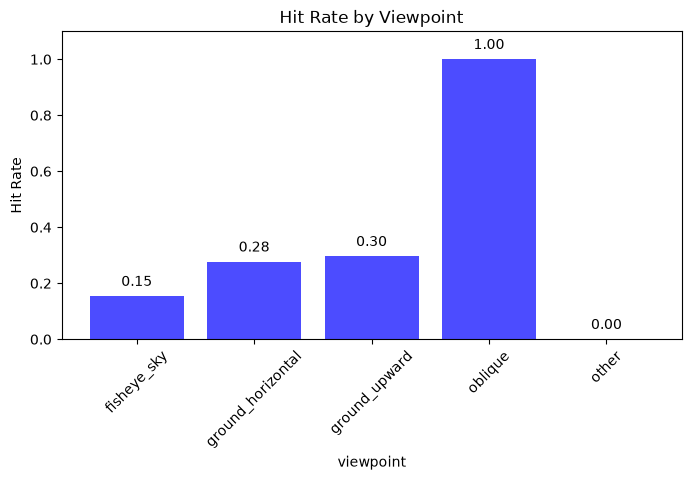

In [18]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

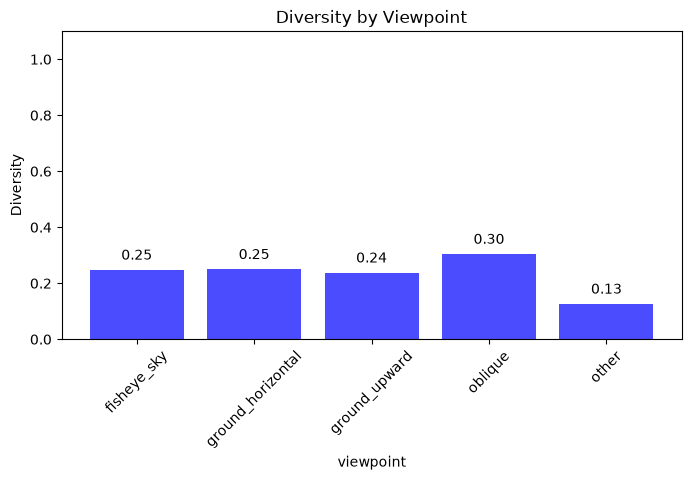

In [19]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

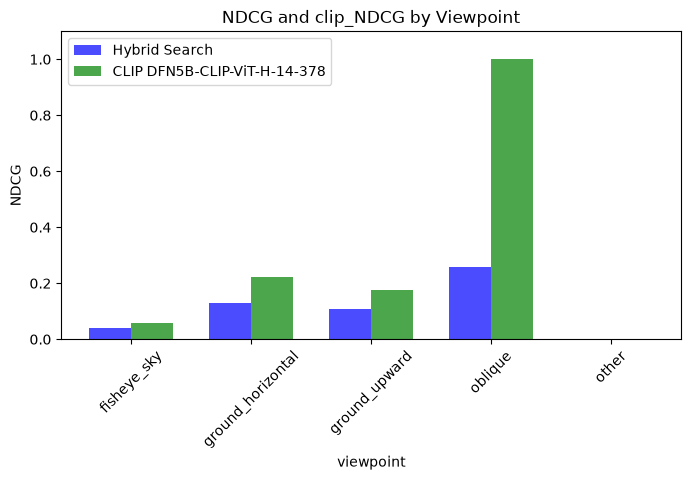

In [20]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

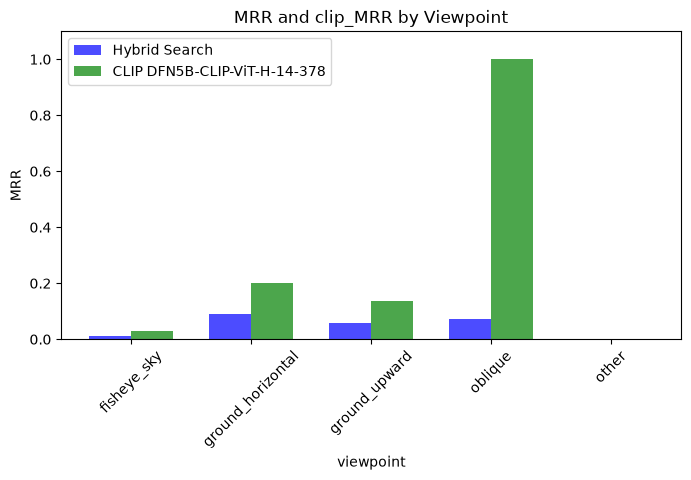

In [21]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Lighting

In [22]:
# Group
lighting_metrics = df.groupby(['lighting']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
lighting_metrics = lighting_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = lighting_metrics
x_column = 'lighting'
title = 'Lighting'

metrics

,lighting,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,bright,275,5,270,5,270,0.018182,0.018182,0.049351,0.272727,0.087758,0.115528,0.032197,0.063131,0.253544
1,day,1250,20,1230,18,1232,0.016000,0.014400,0.071020,0.320000,0.118081,0.232582,0.062665,0.203690,0.245475
2,dusk,400,4,396,4,396,0.010000,0.010000,0.056027,0.250000,0.124272,0.164433,0.094223,0.135417,0.245892
3,night,650,5,645,2,648,0.007692,0.003077,0.007898,0.076923,0.024289,0.027012,0.010096,0.012500,0.222708
4,overcast_light,300,3,297,3,297,0.010000,0.010000,0.057870,0.250000,0.122839,0.189187,0.092909,0.173611,0.287624


### Accuracy

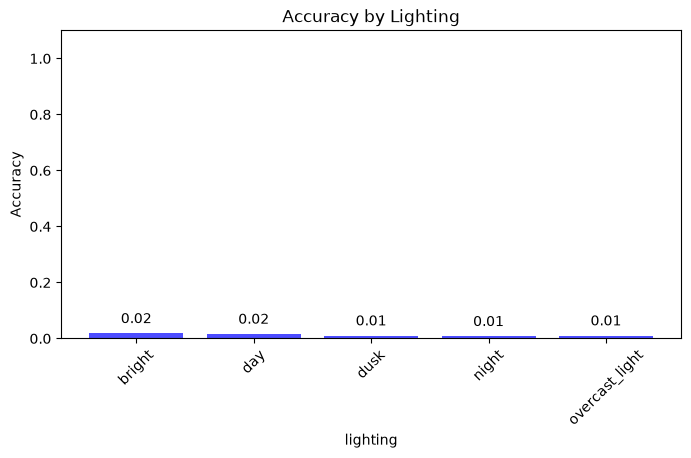

In [23]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

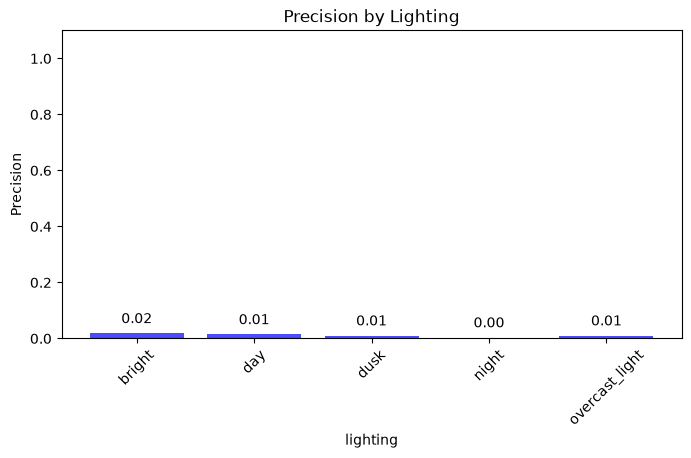

In [24]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

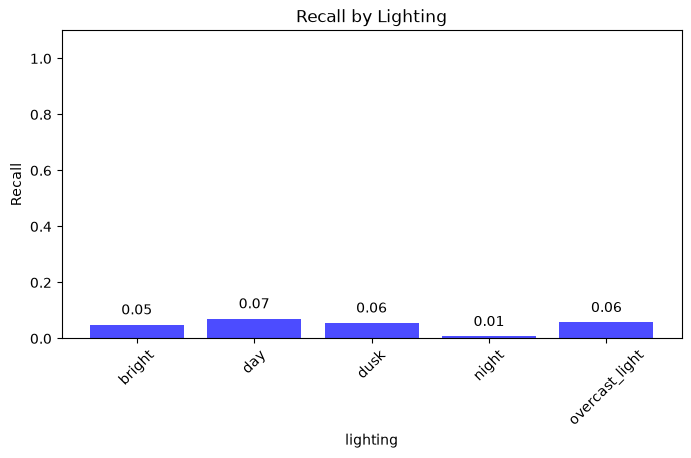

In [25]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

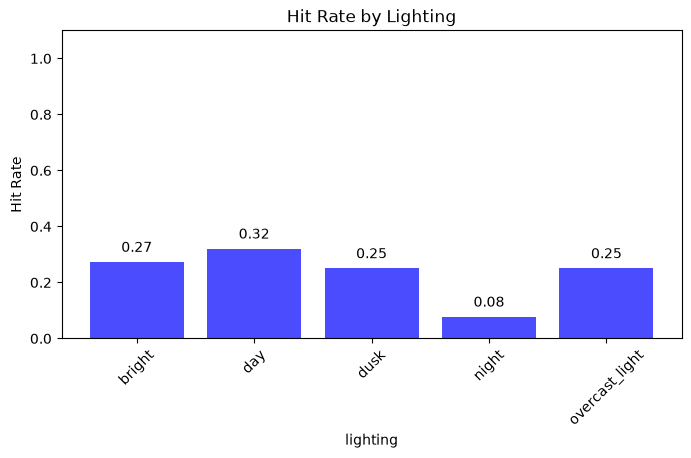

In [26]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

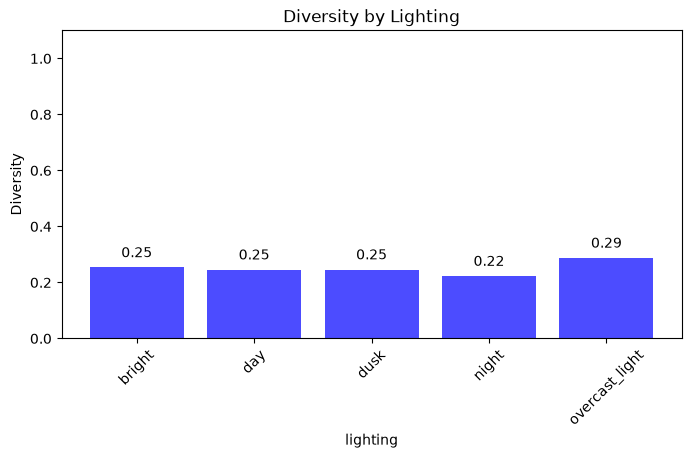

In [27]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

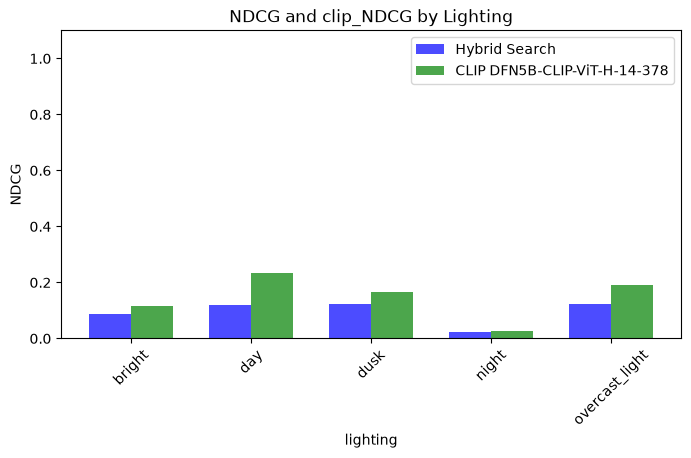

In [28]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

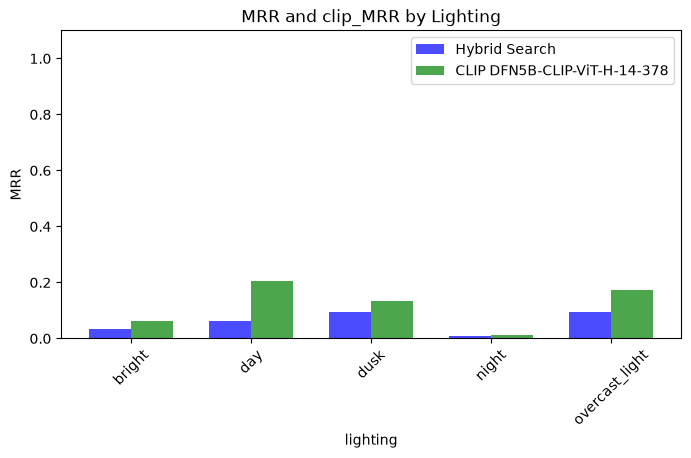

In [29]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Confounder Type

In [30]:
# Group
confounder_metrics = df.groupby('confounder_type').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

#rename columns
confounder_metrics = confounder_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = confounder_metrics
x_column = 'confounder_type'
title = 'Confounder Type'

metrics

,confounder_type,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,fog,25,1,24,1,24,0.040000,0.040000,0.200000,1.000000,0.259304,1.000000,0.071429,1.000000,0.304165
1,none,2200,30,2170,27,2173,0.013636,0.012273,0.056847,0.261364,0.110305,0.180369,0.068566,0.153833,0.247168
2,sun_glare,600,6,594,4,596,0.010000,0.006667,0.028646,0.166667,0.041548,0.067955,0.011132,0.038194,0.244563
3,unknown,50,0,50,0,50,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.157213


### Accuracy

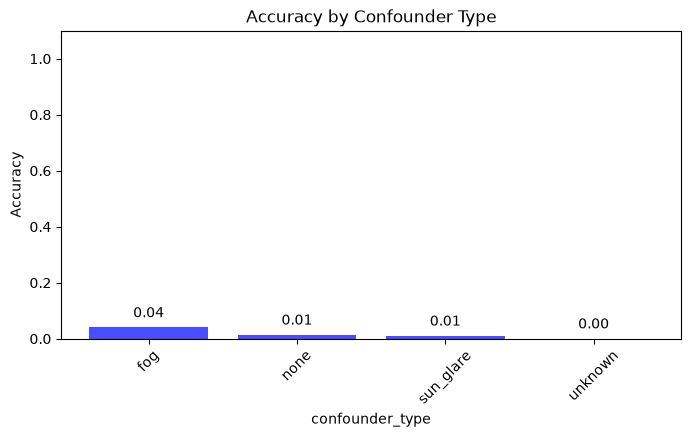

In [31]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

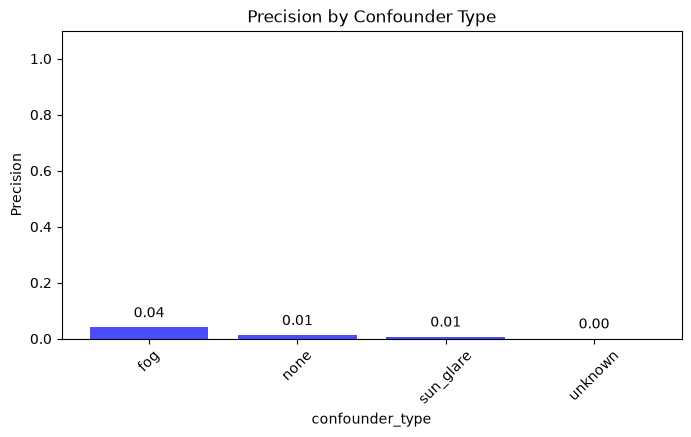

In [32]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

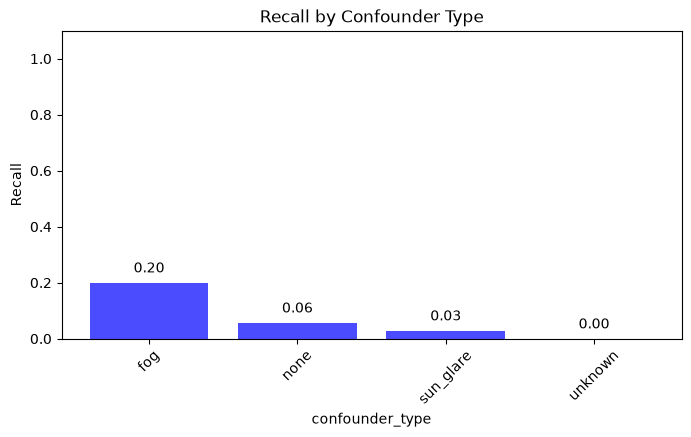

In [33]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

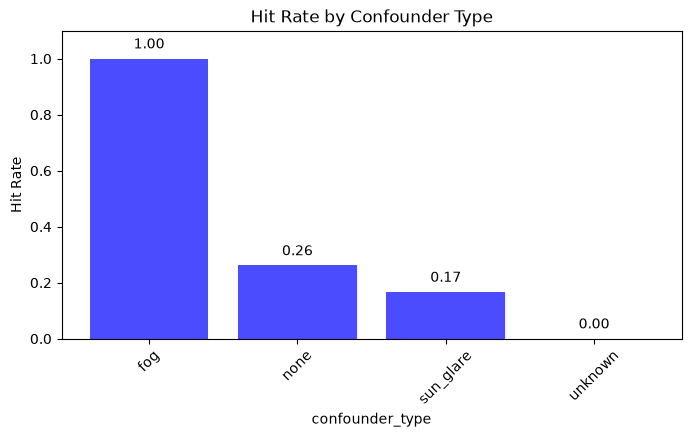

In [34]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

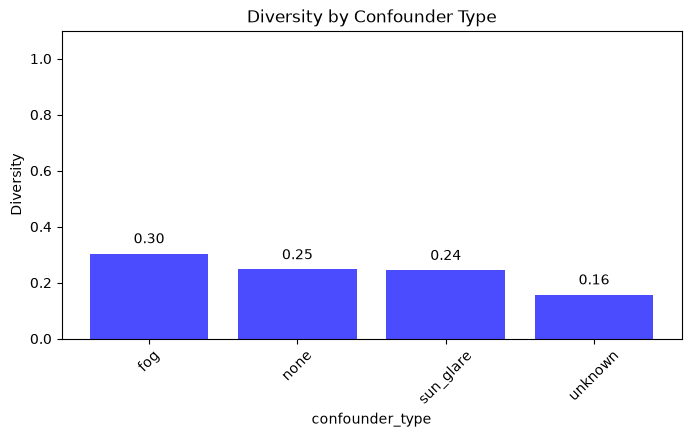

In [35]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

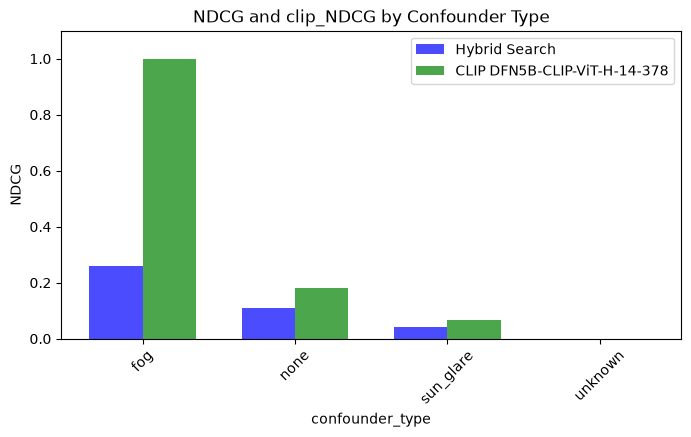

In [36]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

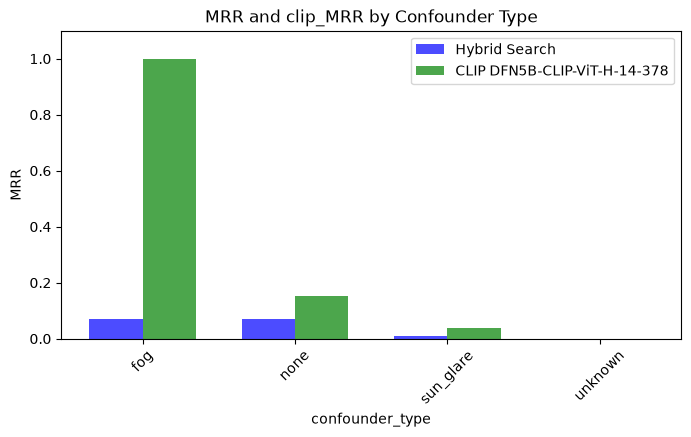

In [37]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Occlusion Present

In [38]:
# Group
occlusion_metrics = df.groupby('occlusion_present').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
occlusion_metrics['occlusion_present'] = occlusion_metrics['occlusion_present'].map({True: 'True', False: 'False'})

#rename columns
occlusion_metrics = occlusion_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = occlusion_metrics
x_column = 'occlusion_present'
title = 'Occlusion Present'

metrics

,occlusion_present,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1900,26,1874,24,1876,0.013684,0.012632,0.062482,0.263158,0.115197,0.203308,0.074058,0.182383,0.238712
1,True,975,11,964,8,967,0.011282,0.008205,0.029268,0.205128,0.056623,0.078257,0.019076,0.040842,0.258892


### Accuracy

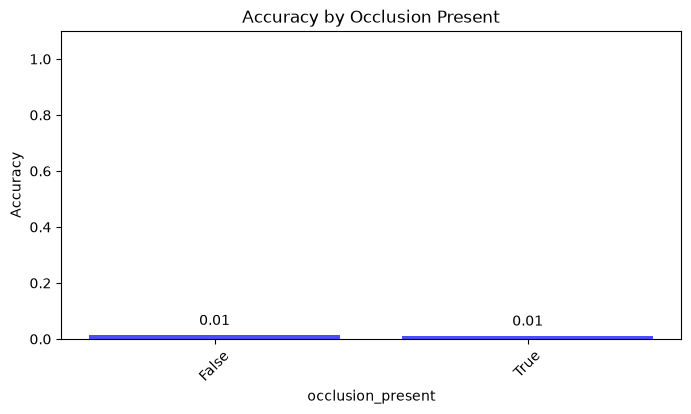

In [39]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

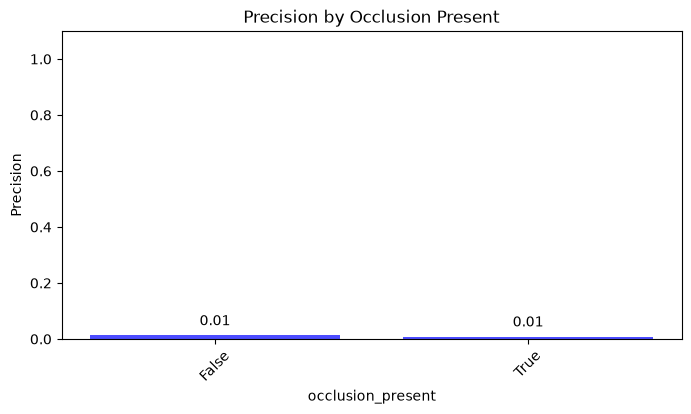

In [40]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

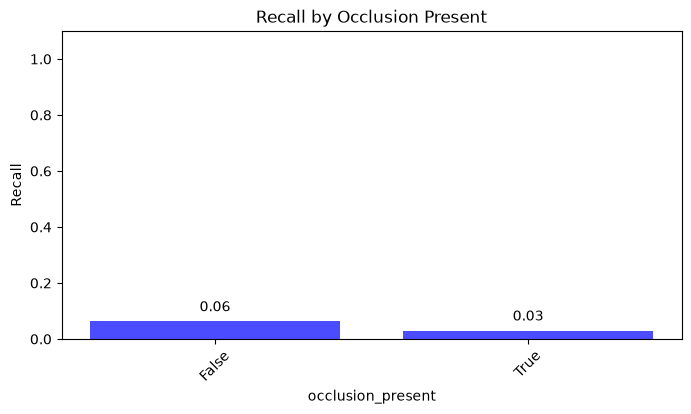

In [41]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

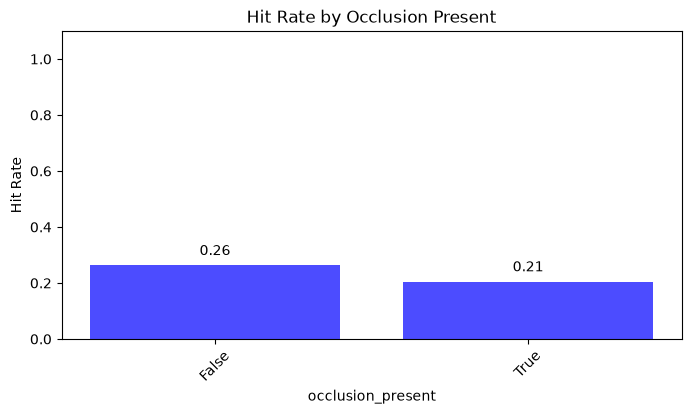

In [42]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

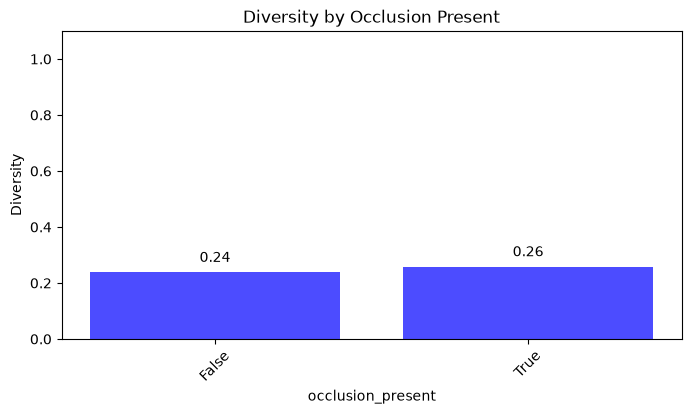

In [43]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

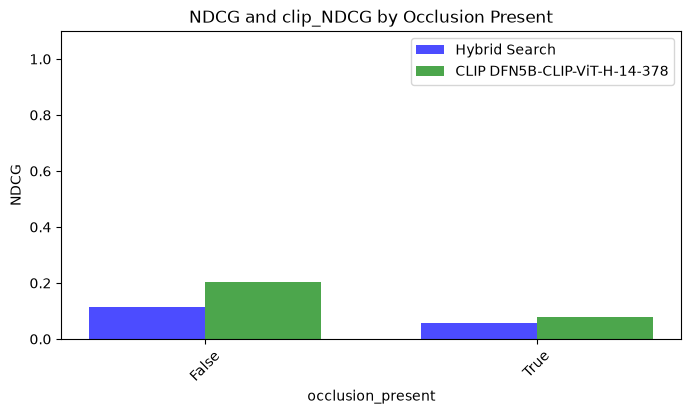

In [44]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

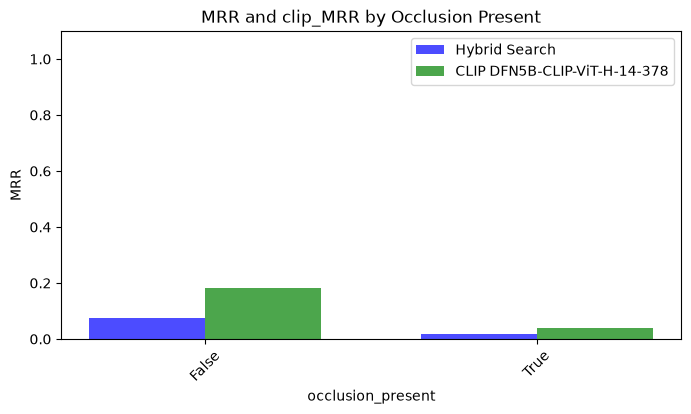

In [45]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Multiple Cloud Types

In [46]:
# Group
multiple_cloud_types_metrics = df.groupby('multiple_cloud_types').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
multiple_cloud_types_metrics['multiple_cloud_types'] = multiple_cloud_types_metrics['multiple_cloud_types'].map({True: 'True', False: 'False'})

#rename columns
multiple_cloud_types_metrics = multiple_cloud_types_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = multiple_cloud_types_metrics
x_column = 'multiple_cloud_types'
title = 'Multiple Cloud Types'

metrics

,multiple_cloud_types,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1700,21,1679,16,1684,0.012353,0.009412,0.045565,0.220588,0.086608,0.152382,0.053831,0.131063,0.238092
1,True,1175,16,1159,16,1159,0.013617,0.013617,0.059397,0.276596,0.107957,0.173222,0.057700,0.139184,0.256354


### Accuracy

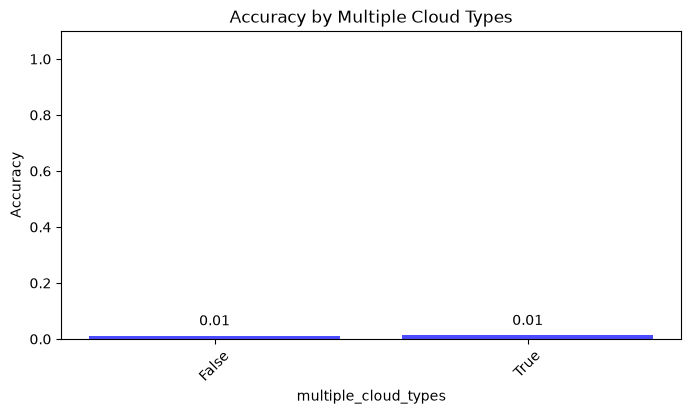

In [47]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

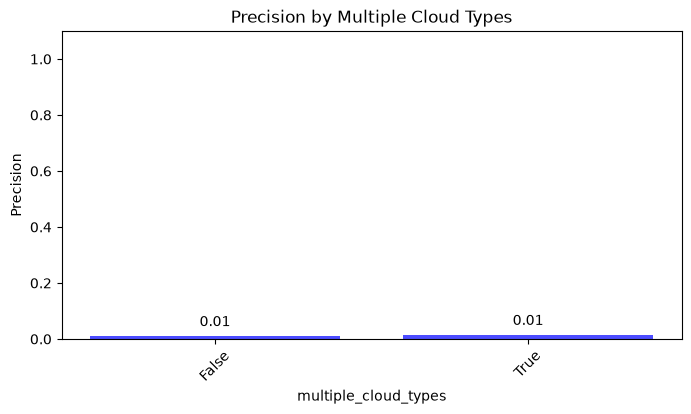

In [48]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

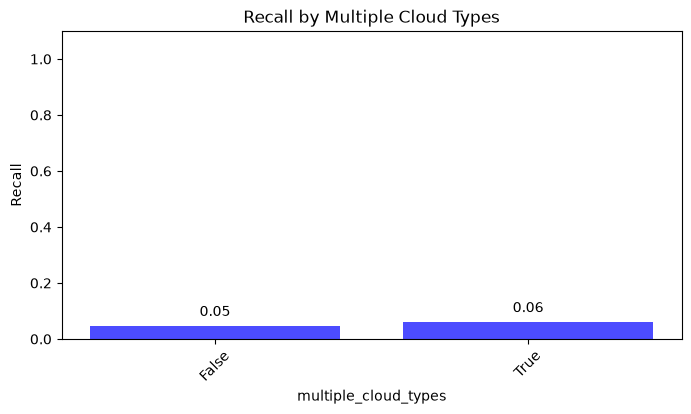

In [49]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

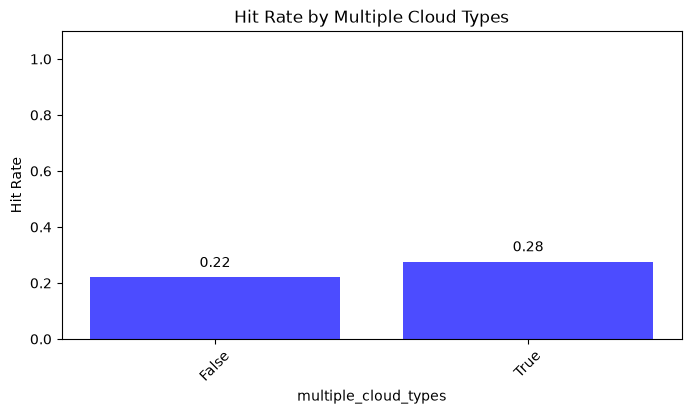

In [50]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

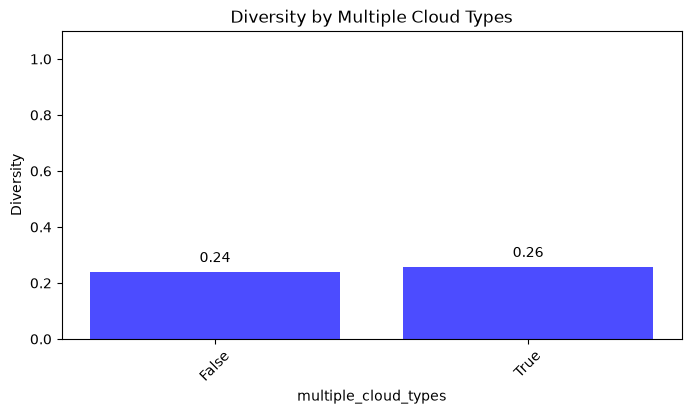

In [51]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

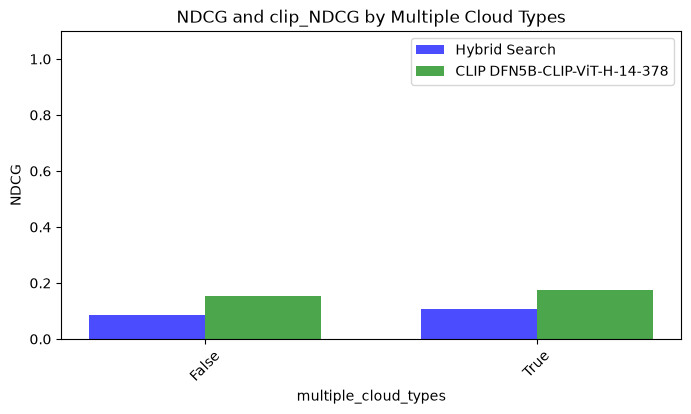

In [52]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

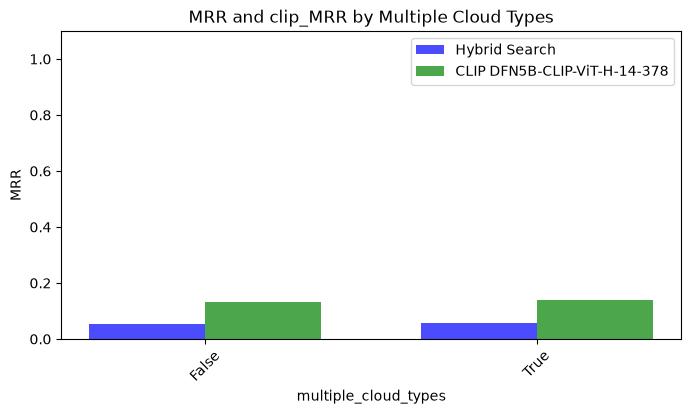

In [53]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Horizon Visible

In [54]:
# Group
horizon_visible_metrics = df.groupby('horizon_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
horizon_visible_metrics['horizon_visible'] = horizon_visible_metrics['horizon_visible'].map({True: 'True', False: 'False'})

#rename columns
horizon_visible_metrics = horizon_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = horizon_visible_metrics
x_column = 'horizon_visible'
title = 'Horizon Visible'

metrics

,horizon_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,600,8,592,6,594,0.013333,0.010000,0.039418,0.250000,0.124910,0.129404,0.101794,0.092824,0.234815
1,True,2275,29,2246,26,2249,0.012747,0.011429,0.054330,0.241758,0.087533,0.169206,0.043180,0.145343,0.248388


### Accuracy

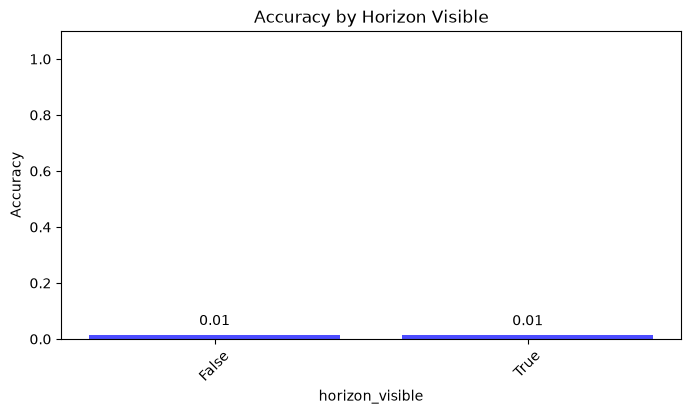

In [55]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

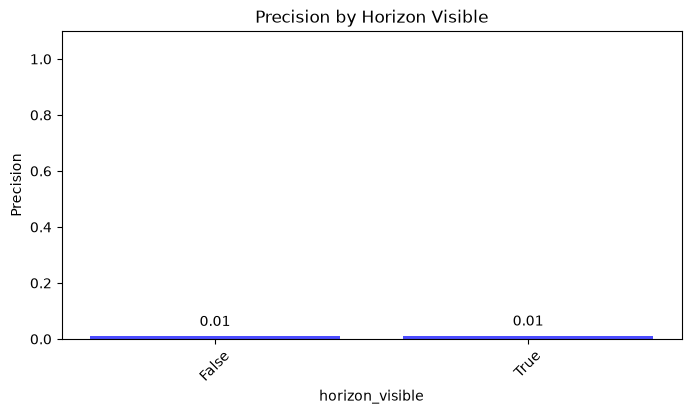

In [56]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

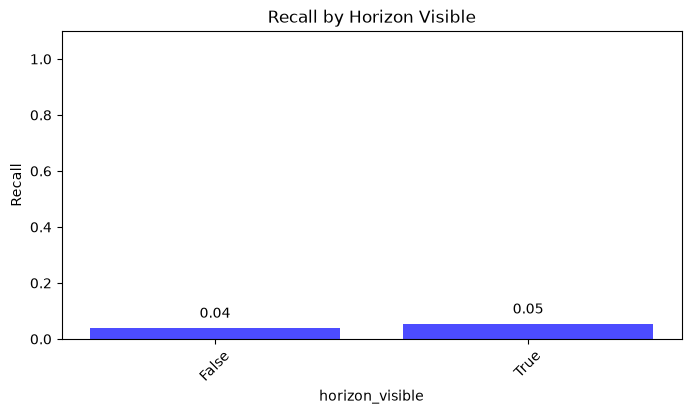

In [57]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

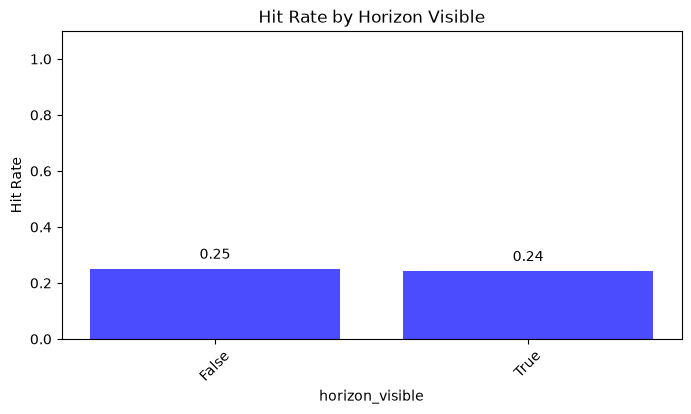

In [58]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

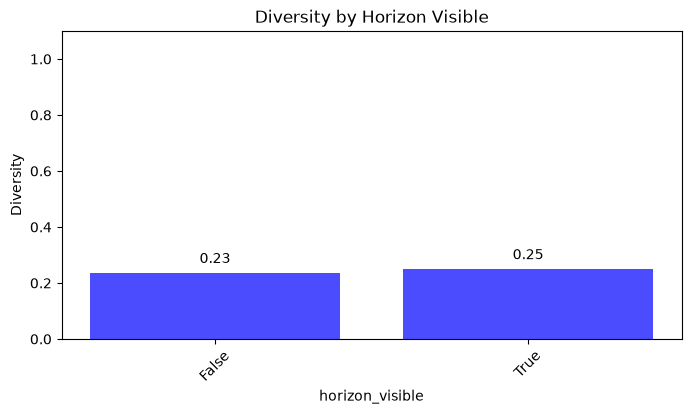

In [59]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

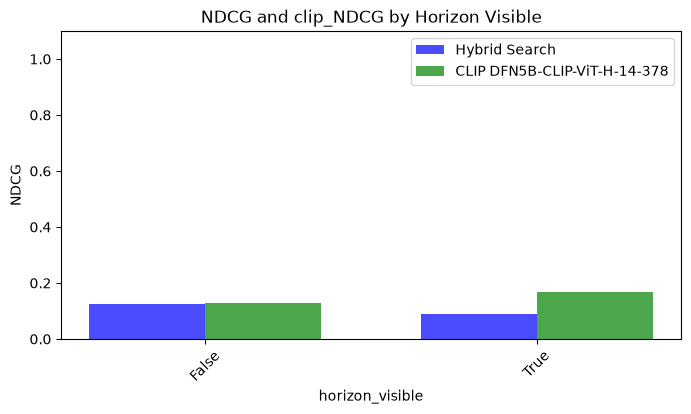

In [60]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

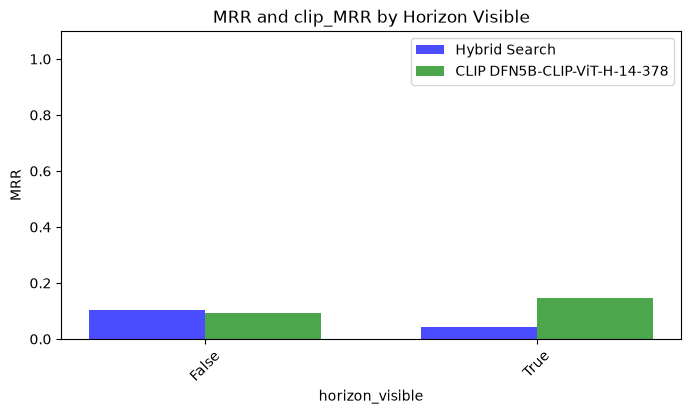

In [61]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Ground Visible

In [62]:
# Group
ground_visible_metrics = df.groupby('ground_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
ground_visible_metrics['ground_visible'] = ground_visible_metrics['ground_visible'].map({True: 'True', False: 'False'})

#rename columns
ground_visible_metrics = ground_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = ground_visible_metrics
x_column = 'ground_visible'
title = 'Ground Visible'

metrics

,ground_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,475,11,464,10,465,0.023158,0.021053,0.073527,0.473684,0.209179,0.305217,0.146961,0.248830,0.232051
1,True,2400,26,2374,22,2378,0.010833,0.009167,0.046803,0.197917,0.072801,0.132336,0.037293,0.111731,0.248228


### Accuracy

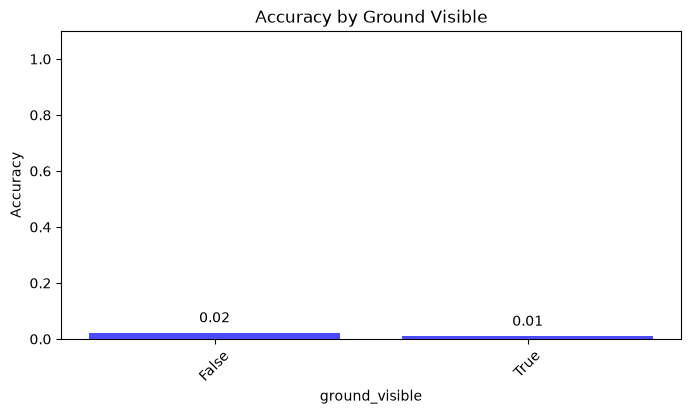

In [63]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

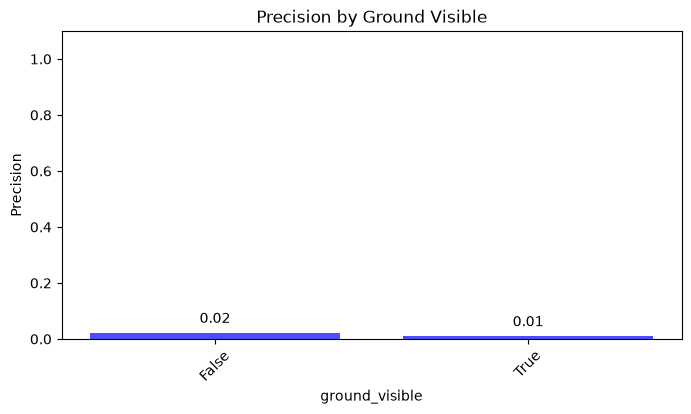

In [64]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

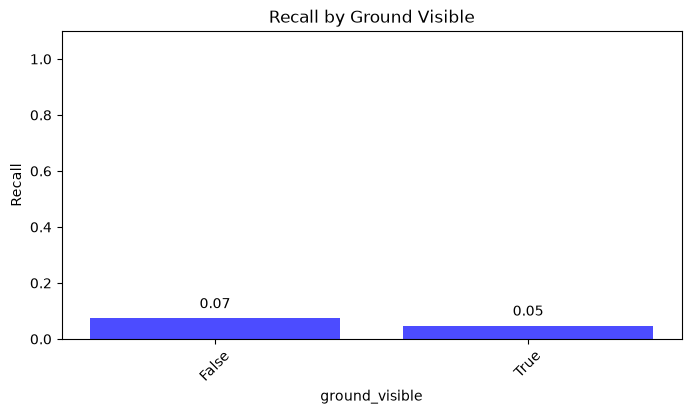

In [65]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

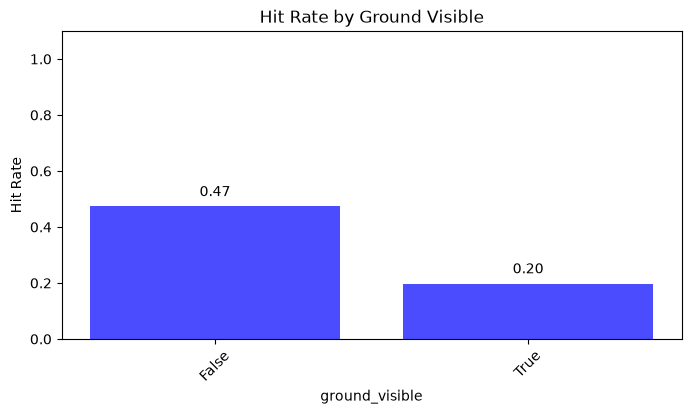

In [66]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

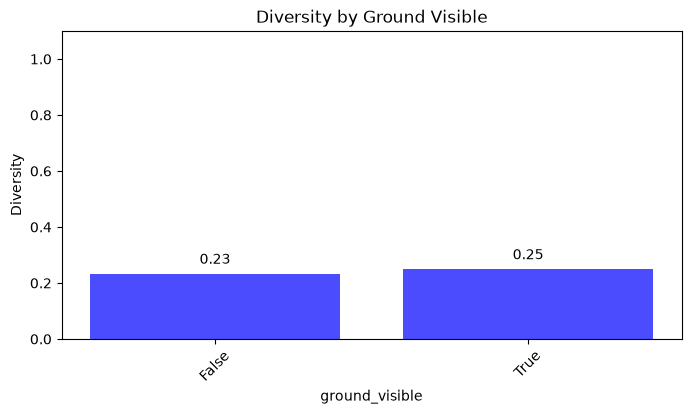

In [67]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

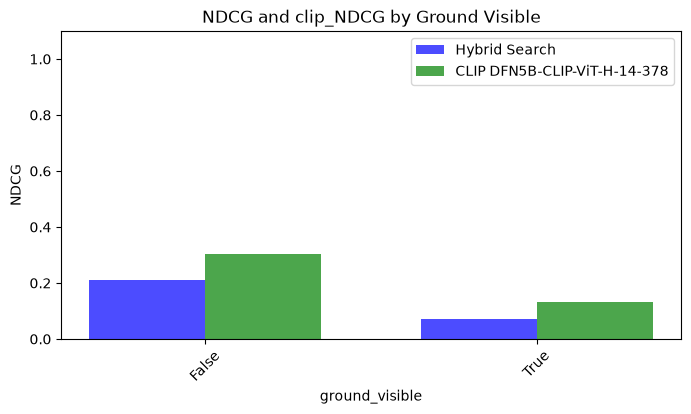

In [68]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

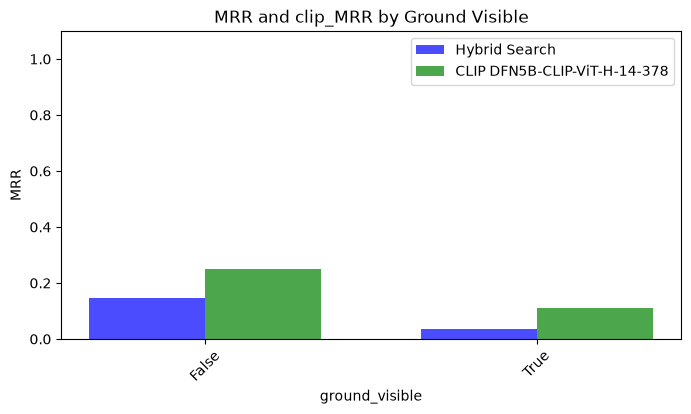

In [69]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Sun Visible

In [70]:
# Group
sun_visible_metrics = df.groupby('sun_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
sun_visible_metrics['sun_visible'] = sun_visible_metrics['sun_visible'].map({True: 'True', False: 'False'})

#rename columns
sun_visible_metrics = sun_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = sun_visible_metrics
x_column = 'sun_visible'
title = 'Sun Visible'

metrics

,sun_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2450,33,2417,29,2421,0.013469,0.011837,0.056106,0.255102,0.104399,0.177088,0.063106,0.151559,0.246746
1,True,425,4,421,3,422,0.009412,0.007059,0.023039,0.176471,0.043074,0.067576,0.011058,0.035364,0.238692


### Accuracy

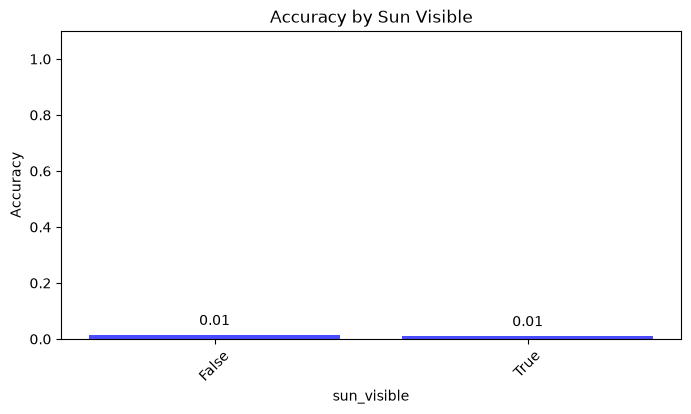

In [71]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

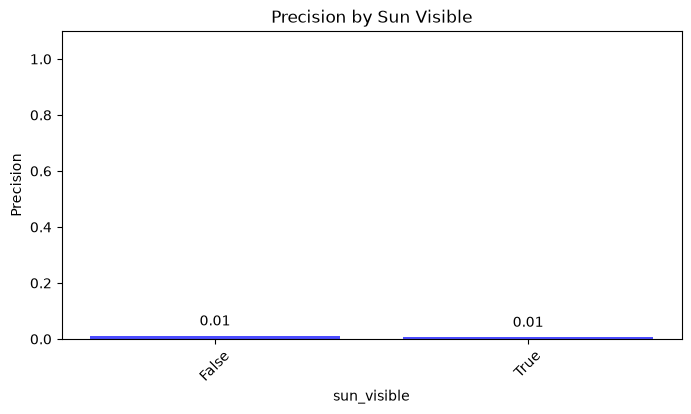

In [72]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

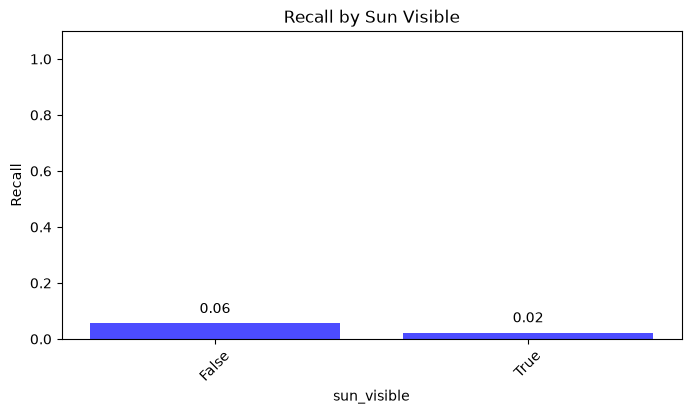

In [73]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

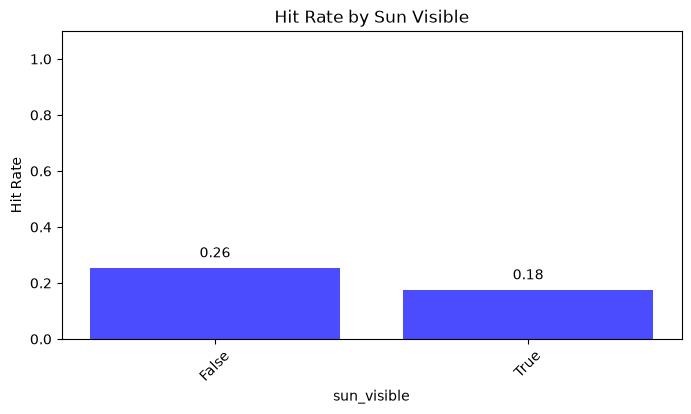

In [74]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

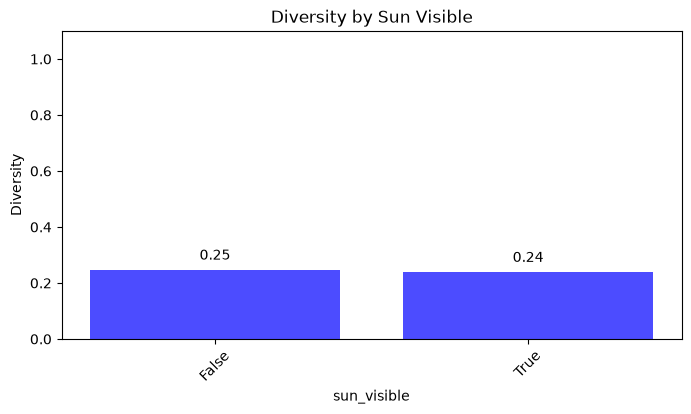

In [75]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

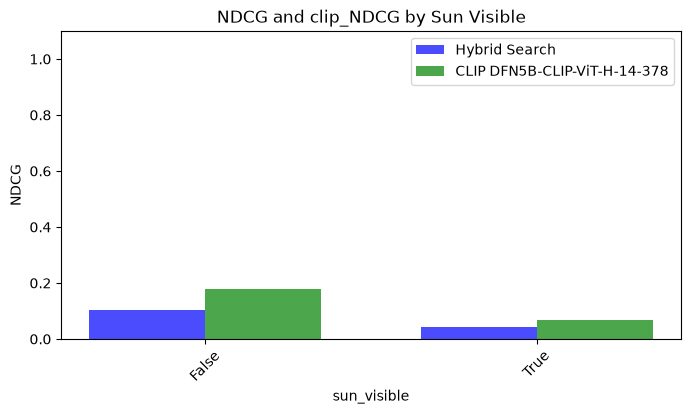

In [76]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

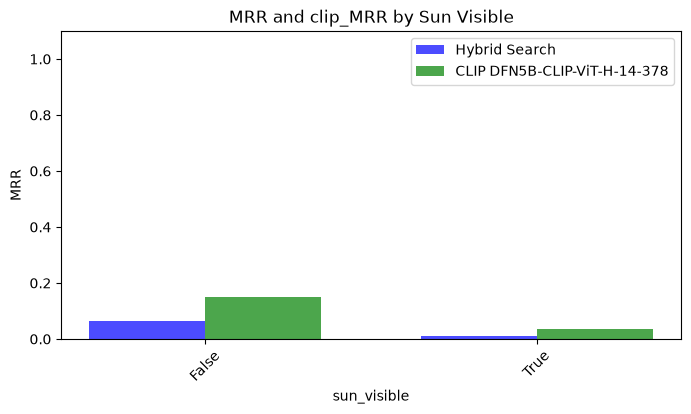

In [77]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Precipitation Visible

In [78]:
# Group
precipitation_visible_metrics = df.groupby('precipitation_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
precipitation_visible_metrics['precipitation_visible'] = precipitation_visible_metrics['precipitation_visible'].map({True: 'True', False: 'False'})

#rename columns
precipitation_visible_metrics = precipitation_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = precipitation_visible_metrics
x_column = 'precipitation_visible'
title = 'Precipitation Visible'

metrics

,precipitation_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2800,35,2765,31,2769,0.012500,0.011071,0.050804,0.241071,0.093732,0.156280,0.053920,0.129053,0.246950
1,True,75,2,73,1,74,0.026667,0.013333,0.066667,0.333333,0.155113,0.333333,0.111111,0.333333,0.193504


### Accuracy

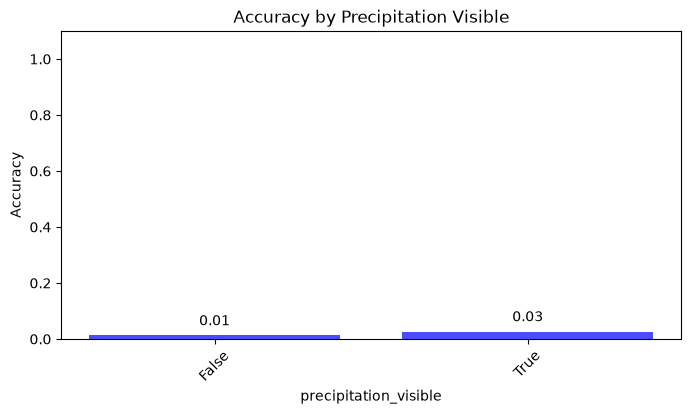

In [79]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

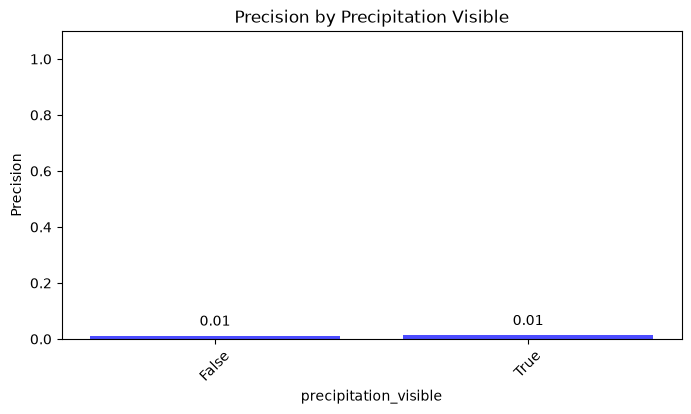

In [80]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

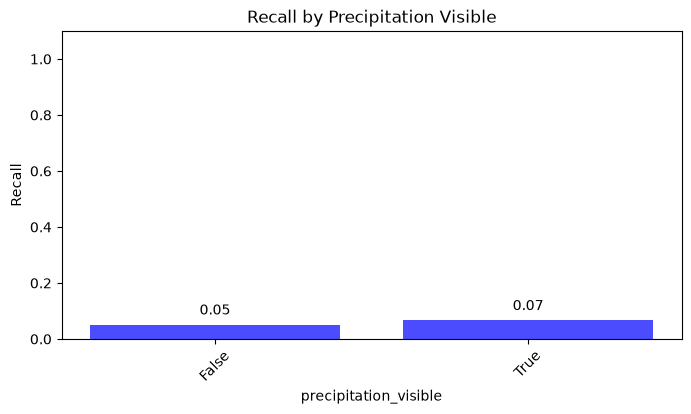

In [81]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

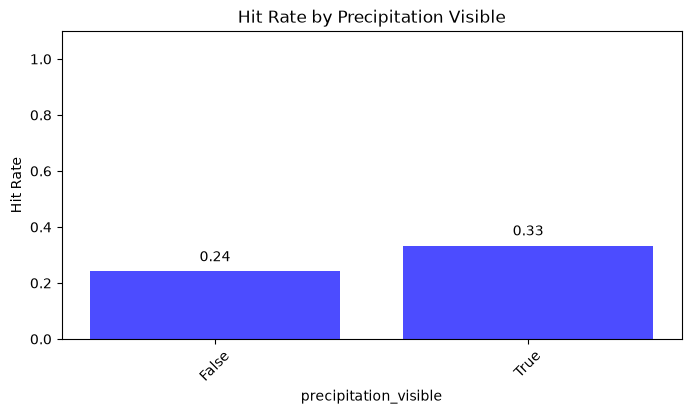

In [82]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

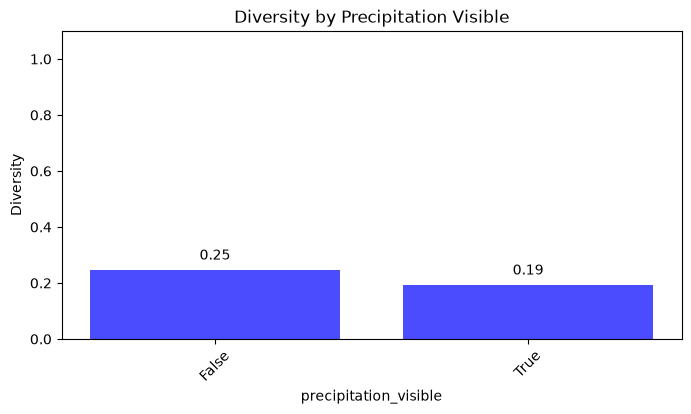

In [83]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

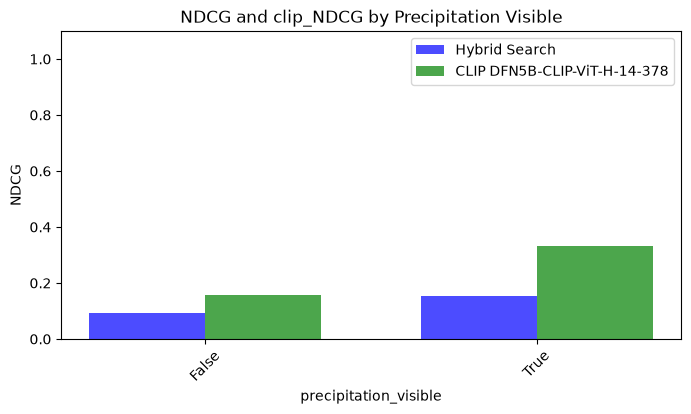

In [84]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

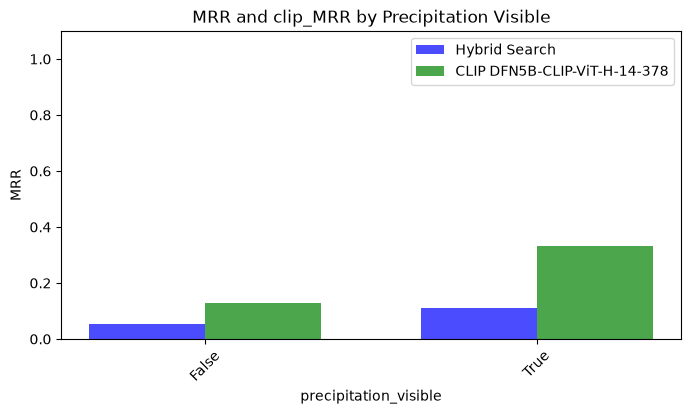

In [85]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Overcast

In [86]:
# Group
overcast_metrics = df.groupby('overcast').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
overcast_metrics['overcast'] = overcast_metrics['overcast'].map({True: 'True', False: 'False'})

#rename columns
overcast_metrics = overcast_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = overcast_metrics
x_column = 'overcast'
title = 'Overcast'

metrics

,overcast,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2275,33,2242,29,2246,0.014505,0.012747,0.057095,0.274725,0.104278,0.178386,0.057775,0.146930,0.241486
1,True,600,4,596,3,597,0.006667,0.005000,0.028935,0.125000,0.061419,0.094593,0.046454,0.086806,0.260986


### Accuracy

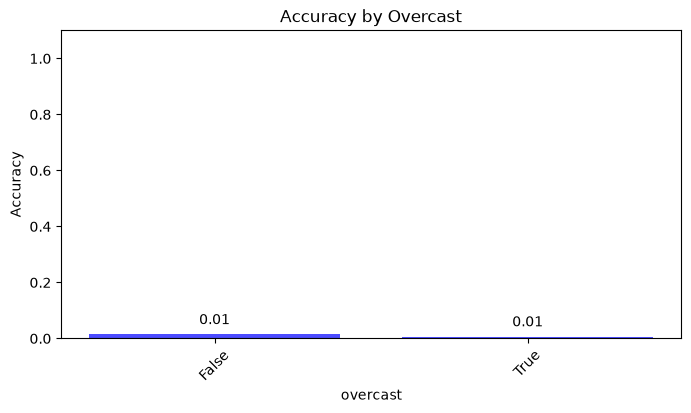

In [87]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

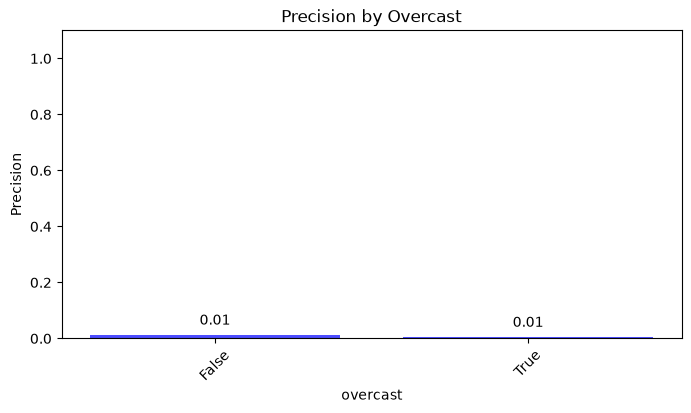

In [88]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

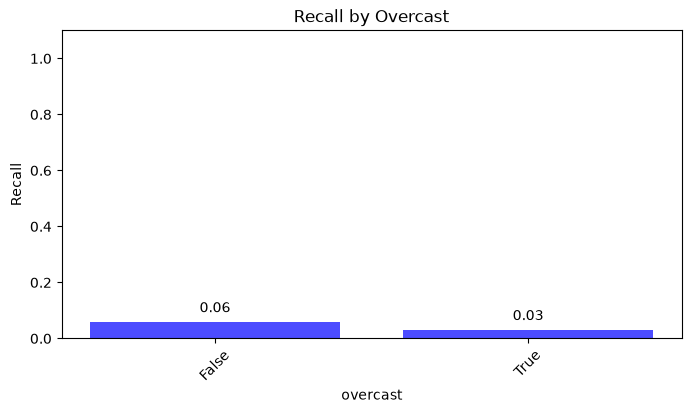

In [89]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

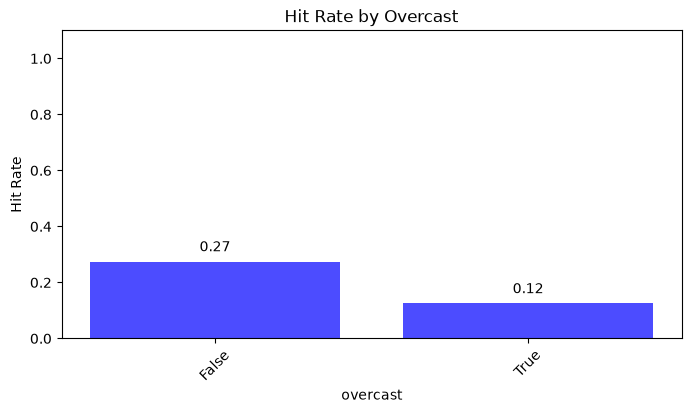

In [90]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

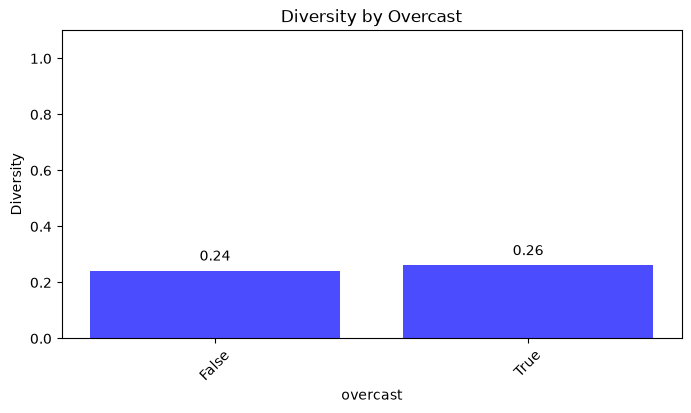

In [91]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

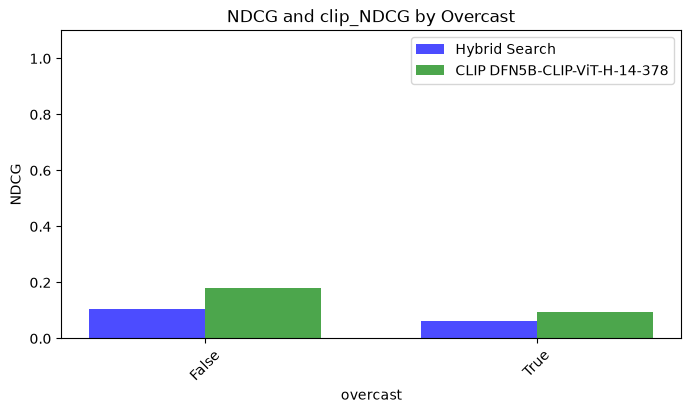

In [92]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

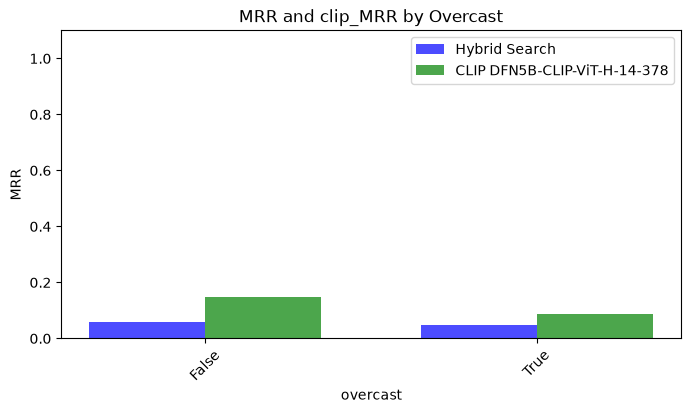

In [93]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Multiple Layers

In [94]:
# Group
multiple_layers_metrics = df.groupby('multiple_layers').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
multiple_layers_metrics['multiple_layers'] = multiple_layers_metrics['multiple_layers'].map({True: 'True', False: 'False'})

#rename columns
multiple_layers_metrics = multiple_layers_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = multiple_layers_metrics
x_column = 'multiple_layers'
title = 'Multiple Layers'

metrics

,multiple_layers,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,1550,18,1532,14,1536,0.011613,0.009032,0.041372,0.209677,0.074331,0.134870,0.037535,0.111489,0.241399
1,True,1325,19,1306,18,1307,0.014340,0.013585,0.062736,0.283019,0.119901,0.191348,0.076325,0.161164,0.250418


### Accuracy

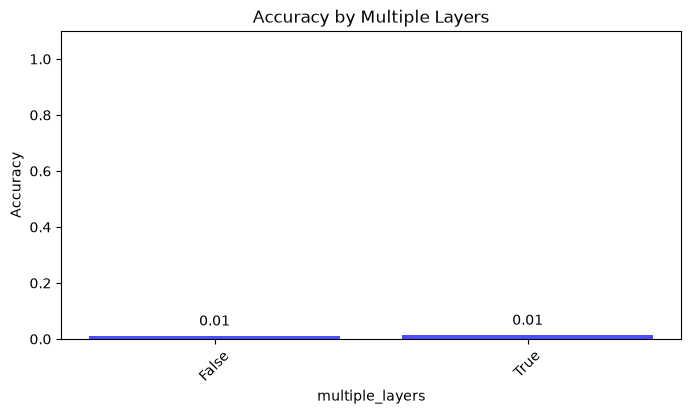

In [95]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

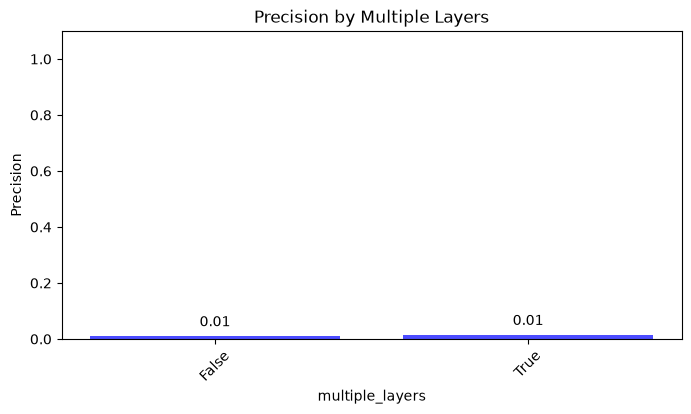

In [96]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

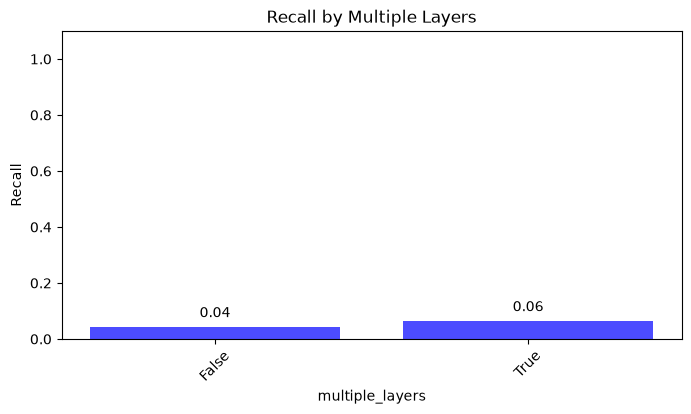

In [97]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

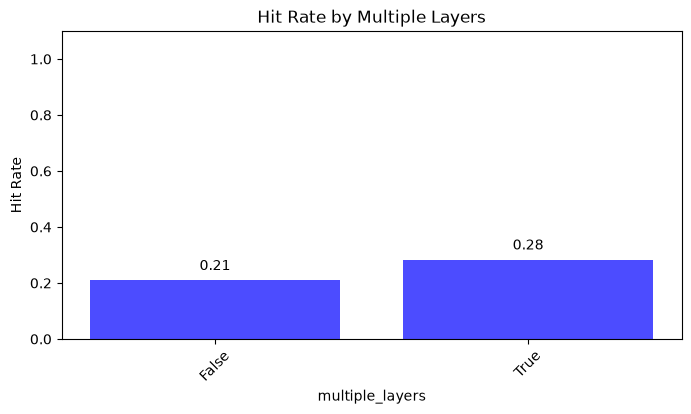

In [98]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

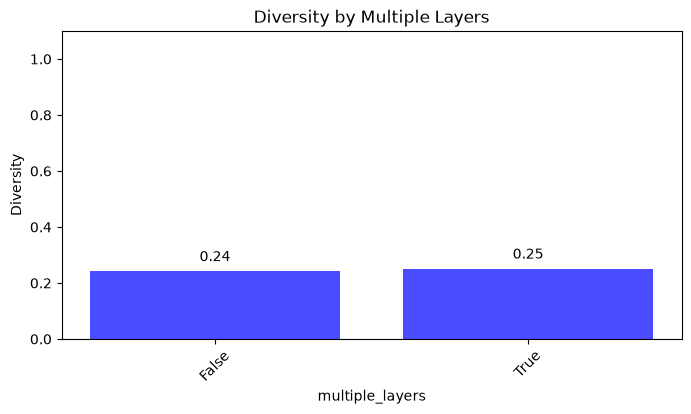

In [99]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

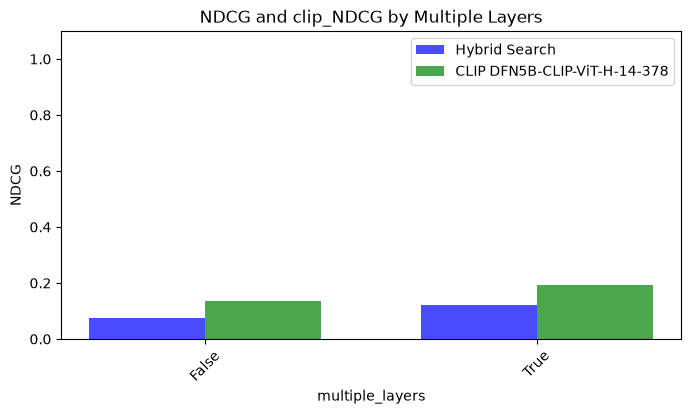

In [100]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

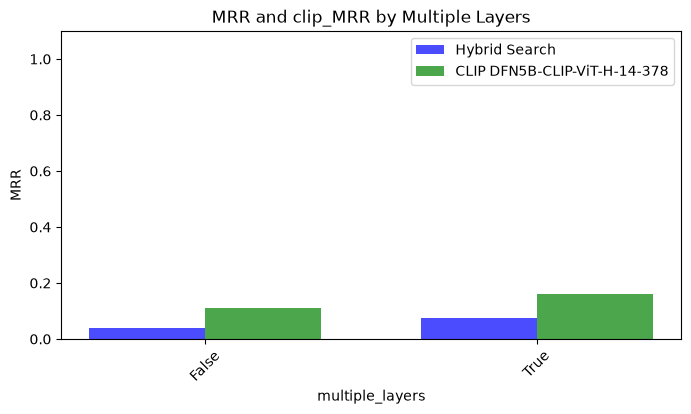

In [101]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Storm Visible

In [102]:
# Group
storm_visible_metrics = df.groupby('storm_visible').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

# use true and false instead of 1 and 0
storm_visible_metrics['storm_visible'] = storm_visible_metrics['storm_visible'].map({True: 'True', False: 'False'})

#rename columns
storm_visible_metrics = storm_visible_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = storm_visible_metrics
x_column = 'storm_visible'
title = 'Storm Visible'

metrics

,storm_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,False,2525,30,2495,25,2500,0.011881,0.009901,0.040468,0.217822,0.077157,0.134383,0.042171,0.107630,0.251922
1,True,350,7,343,7,343,0.020000,0.020000,0.128770,0.428571,0.226463,0.352191,0.150935,0.327381,0.199626


### Accuracy

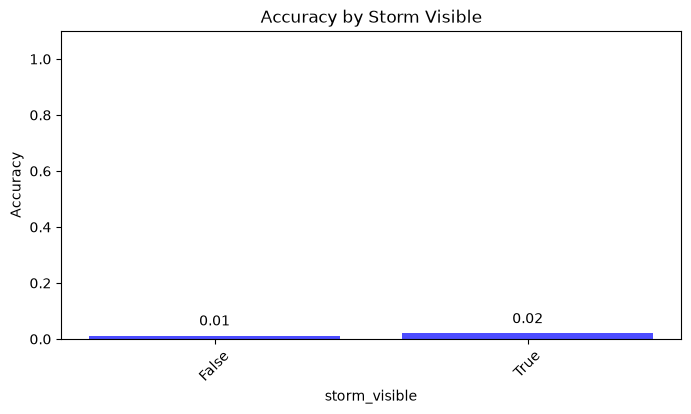

In [103]:
plot_single_bar_metric(metrics, x_column=x_column, metric='accuracy', title=f'Accuracy by {title}', ylabel='Accuracy', xlabel=x_column)

### Precision

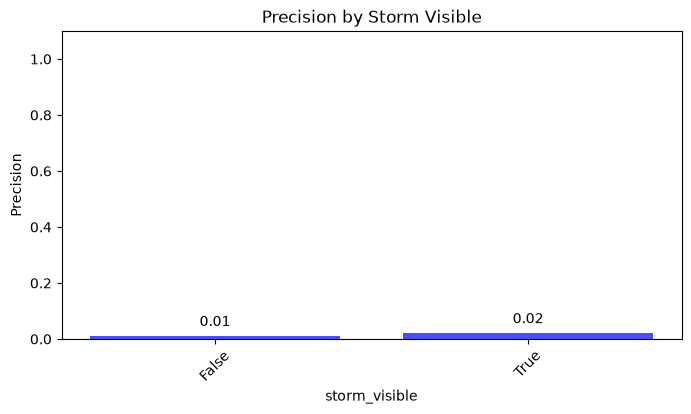

In [104]:
plot_single_bar_metric(metrics, x_column=x_column, metric='precision', title=f'Precision by {title}', ylabel='Precision', xlabel=x_column)

### Recall

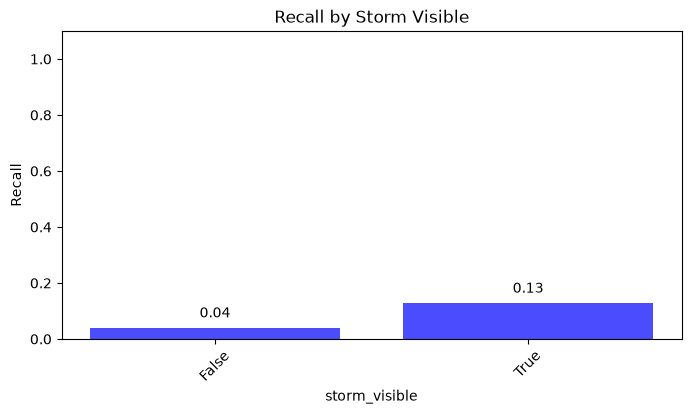

In [105]:
plot_single_bar_metric(metrics, x_column=x_column, metric='recall', title=f'Recall by {title}', ylabel='Recall', xlabel=x_column)

### Hit Rate

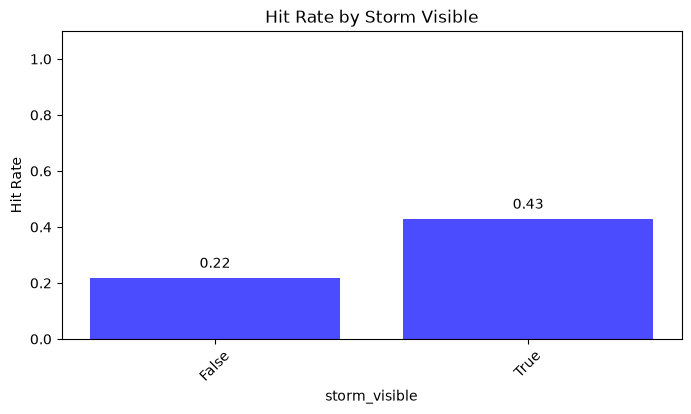

In [106]:
plot_single_bar_metric(metrics, x_column=x_column, metric='hit_rate', title=f'Hit Rate by {title}', ylabel='Hit Rate', xlabel=x_column)

### Diversity

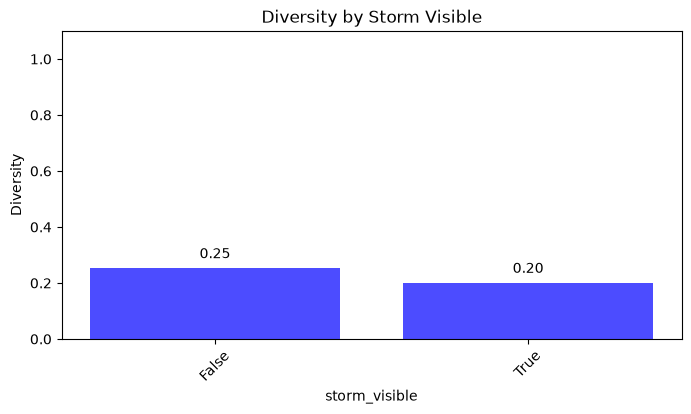

In [107]:
plot_single_bar_metric(metrics, x_column=x_column, metric='diversity', title=f'Diversity by {title}', ylabel='Diversity', xlabel=x_column)

### NDCG

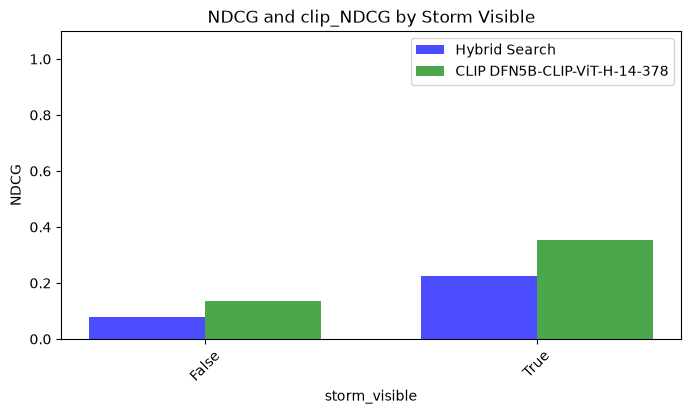

In [108]:
plot_rank_comparison(metrics, x_column=x_column, title=f'NDCG and clip_NDCG by {title}', xlabel=x_column)

### MRR

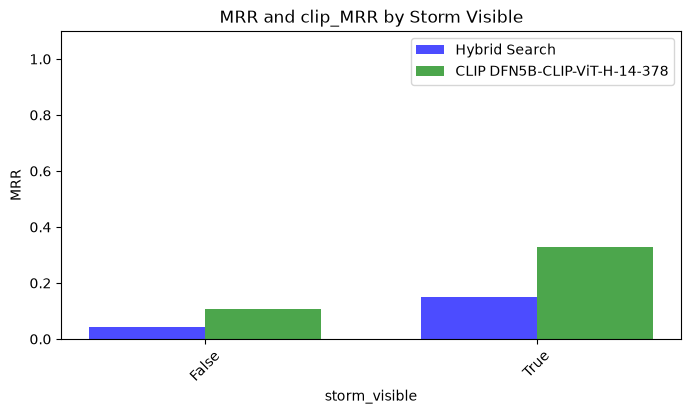

In [109]:
plot_rank_comparison(metrics, x_column=x_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Metrics based on Viewpoint & Sun Visible

Here we will group by Sun Visible and Viewpoint and calculate the sum/mean of each metric to see how the system performs under different Sun Visible and Viewpoint conditions.

>NOTE: due to the large number of combinations you can group by, we will not show all of them. Use this section as a guide if you want to break down the data by different combinations of the metadata.

In [110]:
# Group
view_sun_metrics = df.groupby(['viewpoint', 'sun_visible']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()
view_sun_metrics['sun_visible'] = view_sun_metrics['sun_visible'].map({True: 'True', False: 'False'})

#rename columns
view_sun_metrics = view_sun_metrics.rename(columns={
    'hit': 'hit_rate',
    'rr': 'MRR',
    'clip_rr': 'clip_MRR'
})

# set up graph variables
metrics = view_sun_metrics
x_column = 'viewpoint'
group_column = 'sun_visible'
title = 'Viewpoint & Sun Visible'
colors = {
    "True": "red",
    "False": "green",
}

metrics

,viewpoint,sun_visible,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit_rate,NDCG,clip_NDCG,MRR,clip_MRR,diversity
0,fisheye_sky,False,700,6,694,3,697,0.008571,0.004286,0.020975,0.107143,0.031257,0.041325,0.011672,0.022024,0.248151
1,fisheye_sky,True,275,4,271,3,272,0.014545,0.010909,0.035606,0.272727,0.066569,0.104436,0.017090,0.054654,0.246223
2,ground_horizontal,False,1150,17,1133,16,1134,0.014783,0.013913,0.082669,0.282609,0.133815,0.226097,0.091252,0.206522,0.251164
3,ground_horizontal,True,25,0,25,0,25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.187831
4,ground_upward,False,550,9,541,9,541,0.016364,0.016364,0.041287,0.363636,0.133685,0.218048,0.072208,0.169823,0.238594
5,ground_upward,True,125,0,125,0,125,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.232297
6,oblique,False,25,1,24,1,24,0.040000,0.040000,0.200000,1.000000,0.259304,1.000000,0.071429,1.000000,0.304165
7,other,False,25,0,25,0,25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.126120


### Accuracy

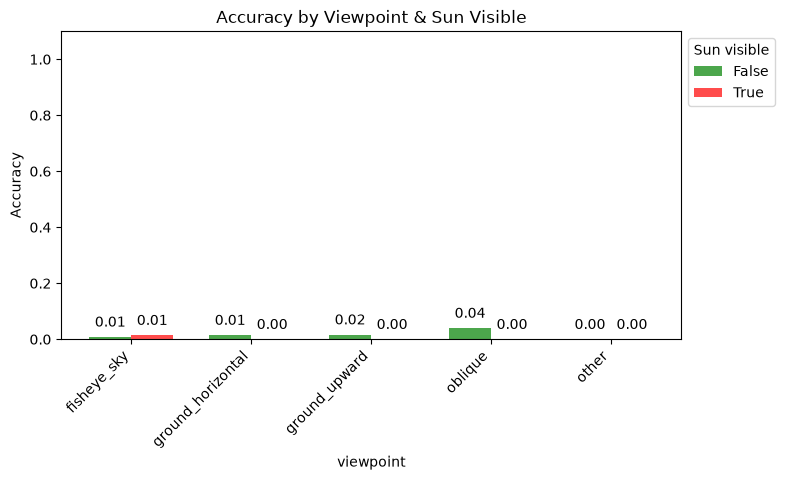

In [111]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='accuracy', 
    color_map=colors, 
    ylabel="Accuracy", 
    xlabel=x_column, 
    title=f"Accuracy by {title}",
)

### Precision

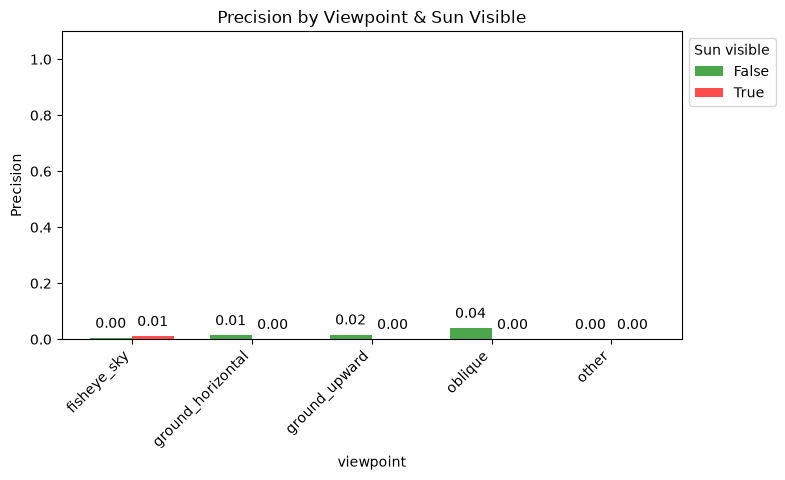

In [112]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='precision', 
    color_map=colors, 
    ylabel="Precision", 
    xlabel=x_column, 
    title=f"Precision by {title}",
)

### Recall

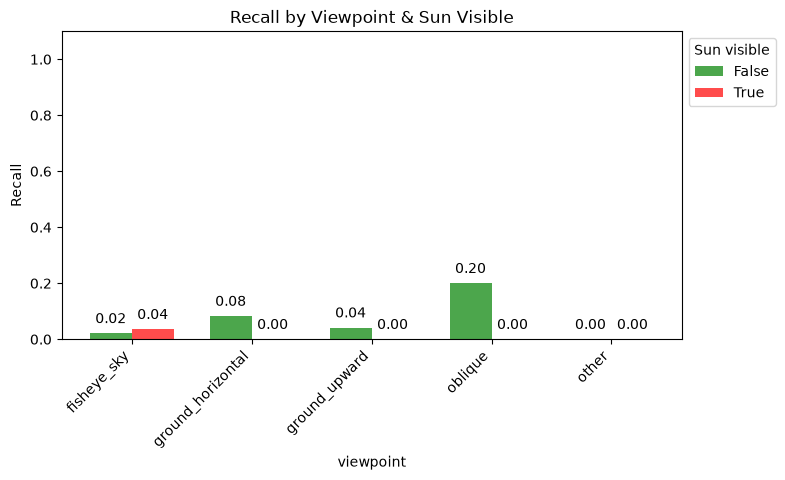

In [113]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='recall', 
    color_map=colors,
    ylabel="Recall", 
    xlabel=x_column, 
    title=f"Recall by {title}",
)


### Hit Rate

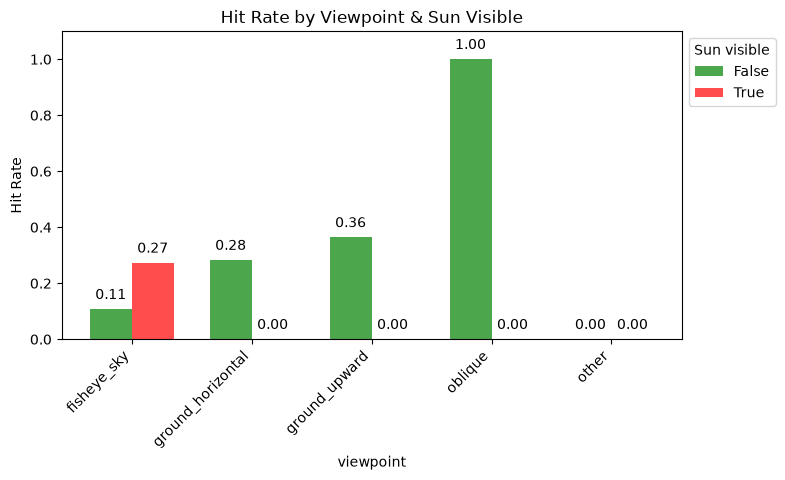

In [114]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='hit_rate', 
    color_map=colors,
    ylabel="Hit Rate", 
    xlabel=x_column, 
    title=f"Hit Rate by {title}",
)

### Diversity

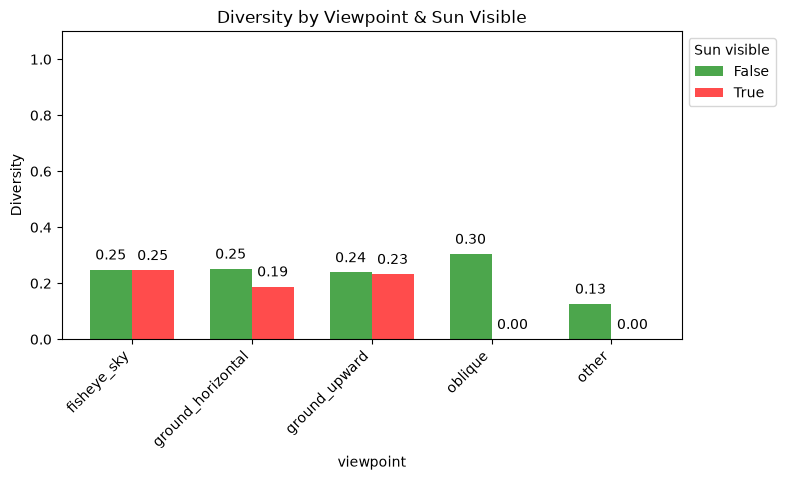

In [115]:
plot_grouped_bar_by_columns(
    metrics, 
    x_column=x_column, 
    color_column=group_column, 
    metric='diversity', 
    color_map=colors,
    ylabel="Diversity", 
    xlabel=x_column, 
    title=f"Diversity by {title}",
)

### NDCG

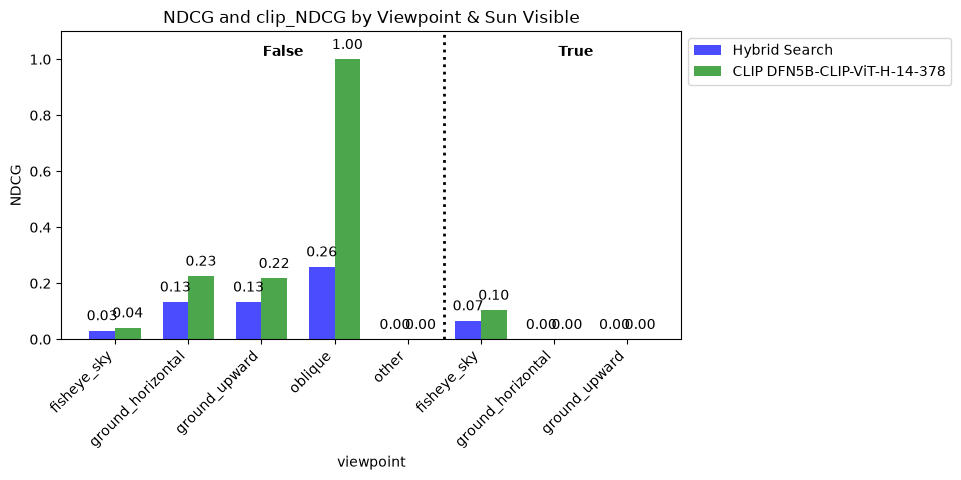

In [116]:
# Sort by group_column so group dividers and labels are correct
_ndcg_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(
    _ndcg_df,
    x_column=x_column,
    group_column=group_column,
    title=f"NDCG and clip_NDCG by {title}",
    xlabel=x_column,
)


### MRR

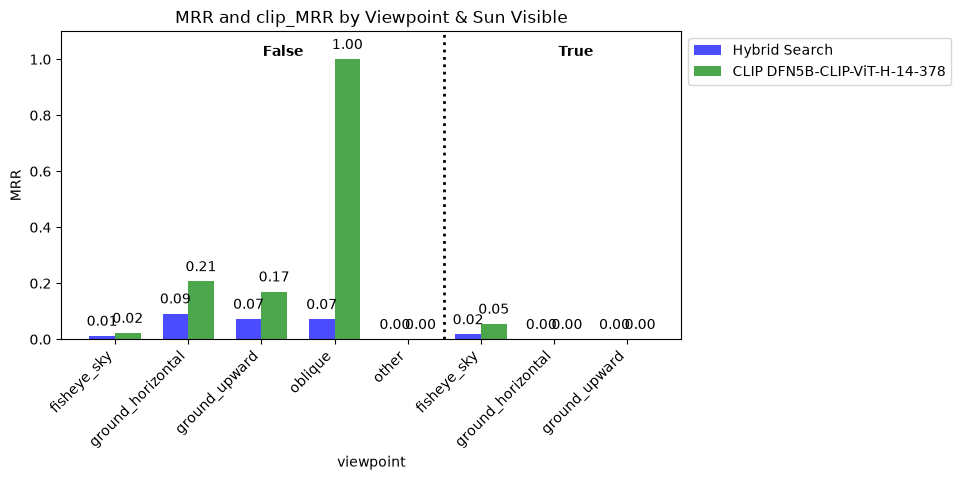

In [117]:
_mrr_df = metrics.sort_values(group_column).reset_index(drop=True)
plot_multi_rank_comparison(_mrr_df, x_column=x_column, group_column=group_column, title=f'MRR and clip_MRR by {title}', xlabel=x_column, metric="MRR")

## Insights & Conclusion

**System Difference**

* **v12:** Weaviate hybrid search over **one fused CLIP index** (caption + image embeddings combined into a single `clip` vector), with the Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. CLIP inference had **no Triton dynamic batching**.
* **v14:**
  * introduced in v13:
    * **Weaviate → Milvus** as the vector database.
    * **Weaviate reranker → Apple CLIP DFN** (`DFN5B-CLIP-ViT-H-14-378`): query text vs stored `image_vector`s.
    * **One fused index → dual indexing**: separate `caption_vector` and `image_vector` fields, blended at query time (`clip_alpha=0.7`).
    * **No Triton batching → Triton dynamic batching** for CLIP (and Gemma when served on Triton), so concurrent embedding/caption requests coalesce into larger GPU batches.
  * v13 additions plus LLM Image Byte Limiting - Caption images are preprocessed before NRP gemma calls: RGB conversion, longest-side cap (`LLM_MAX_IMAGE_SIDE=6144`), and JPEG downscale/quality stepping to stay under `LLM_MAX_IMAGE_BYTES` (12 MiB).
* **v15:**
  * **Two-caption prompt** (`scientific_two_captions_v1`): Gemma emits `long_caption`, `short_caption` (≤55 tokens, visible content only), and 15 `keywords`.
  * **CLIP vs BM25 text split**: `caption_vector` embeds **`short_caption` + `keywords`** in one 77-token CLIP pass (keywords used to fall past the truncation cutoff). BM25 `search_text` still indexes **`long_caption` + keywords**.
  * **Schema**: `long_caption` and `short_caption` stored as separate VARCHAR fields (replacing a single `caption` column).
  * Hybrid weights unchanged (`query_alpha=0.4`, `clip_alpha=0.7`). CLIP DFN still reranks on `image_vector`.
* **v16:**
  * **Query-only** (`SKIP_INDEX=true`): reuse the v15 collections. No recaption and no collection drop. The only IR change is hybrid blend weights at query time.
  * **Blend sweep A–H** on `query_alpha` / `clip_alpha`. Production pick **H**: `query_alpha=0.65`, `clip_alpha=0.7` → **46% image / 20% caption / 35% BM25** (v15 was **28 / 12 / 60**).
  * `clip_alpha` did not move hit sets at `query_alpha≤0.6` (A/C vs v15; F vs B). Sage hit collapses between 0.65 and 0.70 — **E fails the v15 Sage floor**.

---

**Overall Metrics Comparison**

v16 is skip-index blend **H** (`query_alpha=0.65`, `clip_alpha=0.7`) on the v15 Cloudbench collection. **Δ (v16 − v15)** is the blend-only increment. v12 is the Weaviate fused-index reference.

| Metric                   | v12 | v15 | v16 | Δ (v16 − v15) |
| ------------------------ | --- | --- | --- | ------------- |
| **Total Images**         | 2,875 | 2,875 | 2,875 | 0 |
| **Correctly Returned**   | 39 | 38 | 37 | −1 |
| **Incorrectly Returned** | 2,836 | 2,837 | 2,838 | +1 |
| **Relevant Images**      | 36 | 32 | 32 | 0 |
| **Accuracy**             | 0.0136 | 0.0132 | 0.0129 | −0.0003 |
| **Precision**            | 0.0125 | 0.0111 | 0.0111 | 0 |
| **Recall**               | 0.0645 | 0.0521 | 0.0512 | −0.0009 |
| **Hit Rate**             | 0.2696 | 0.2522 | 0.2435 | −0.0087 |
| **Diversity**            | 0.2027 | 0.2559 | 0.2456 | −0.0103 |
| **NDCG** | 0.0935 | 0.1053 | 0.0953 | −0.0099 |
| **clip_NDCG** | 0.1905 | 0.1728 | 0.1609 | −0.0119 |
| **MRR** | 0.0466 | 0.0656 | 0.0554 | −0.0102 |
| **clip_MRR** | 0.1691 | 0.1478 | 0.1344 | −0.0134 |
| **DLQ entries**          | — | 0 | 0 | 0 |

**Alpha sweep (hit / hybrid MRR).** Hit = Success@25. MRR = `rerank_score_reciprocal_rank`.

| Point | Folder | query_alpha | clip_alpha | weights (img / cap / BM25) | Hit | MRR |
| ----- | ------ | ----------- | ---------- | -------------------------- | --- | --- |
| v15 | *(v15 index)* | 0.40 | 0.7 | 28 / 12 / 60 | 25.2% | 0.066 |
| A | `v16_qa04_ca085` | 0.40 | 0.85 | 34 / 6 / 60 | 25.2% | 0.066 |
| C | `v16_qa04_ca05` | 0.40 | 0.50 | 20 / 20 / 60 | 25.2% | 0.066 |
| D | `v16_qa05_ca07` | 0.50 | 0.7 | 35 / 15 / 50 | 25.2% | 0.066 |
| B | `v16_qa06_ca07` | 0.60 | 0.7 | 42 / 18 / 40 | 24.3% | 0.055 |
| F | `v16_qa06_ca085` | 0.60 | 0.85 | 51 / 9 / 40 | 24.3% | 0.055 |
| **H (v16)** | **`v16_qa065_ca07`** | **0.65** | **0.7** | **46 / 20 / 35** | **24.3%** | **0.055** |
| E | `v16_qa07_ca07` | 0.70 | 0.7 | 49 / 21 / 30 | 20.0% | 0.062 |

**Why each `v16_qa*` batch was run.** Folder names encode the knobs (`qa` = `query_alpha`, `ca` = `clip_alpha`). Hybrid weights are `WeightedRanker(query_alpha × clip_alpha, query_alpha × (1 − clip_alpha), 1 − query_alpha)` → image / caption / BM25. All seven jobs are **skip-index** on the v15 collections (no recaption). They were launched in three waves so later jobs could condition on earlier ones.

- **Wave 1 — which knob moves anything?**
  - **A / `v16_qa04_ca085`:** hold `query_alpha=0.4` (v15), raise `clip_alpha` 0.7 → 0.85 (more image, less caption). Test whether the dense image/caption split matters while BM25 is still 60%. **This bench:** No-op vs v15 (25.2% / 0.066). `clip_alpha` dead while BM25 is 60%.
  - **C / `v16_qa04_ca05`:** hold `query_alpha=0.4`, lower `clip_alpha` 0.7 → 0.5 (more caption). Same question, other direction. **This bench:** No-op vs v15 (25.2% / 0.066). Same lock as A, other direction.
  - **B / `v16_qa06_ca07`:** hold `clip_alpha=0.7`, raise `query_alpha` 0.4 → 0.6 (BM25 60% → 40%). Test whether the dense vs BM25 mix is the lever. **This bench:** Soft miss: 25.2% → 24.3%, MRR 0.066 → 0.055. First move; this bench does not want less BM25.
- **Wave 2 — where is the unlock / cliff, and is `clip_alpha` alive once BM25 drops?**
  - **D / `v16_qa05_ca07`:** `query_alpha=0.5`, `clip_alpha=0.7`. Interpolate v15 and B to find where the BM25 lock breaks. **This bench:** No-op vs v15 (25.2% / 0.066). Still BM25-locked at 50%.
  - **E / `v16_qa07_ca07`:** `query_alpha=0.7`, `clip_alpha=0.7`. Push past B: is more dense still worth it, or do Sage/Cloud fall off? **This bench:** Crash: 20.0% / 0.062. Confirms Cloudbench still wants BM25/caption.
  - **F / `v16_qa06_ca085`:** `query_alpha=0.6`, `clip_alpha=0.85`. Retest `clip_alpha` now that BM25 is 40% and no longer locking. **This bench:** Identical to B (24.3% / 0.055). `clip_alpha` still dead after unlock.
- **Wave 3 — sit between the unlock and the cliff.**
  - **H / `v16_qa065_ca07`:** `query_alpha=0.65`, `clip_alpha=0.7`. Between B (first unlock, Sage holds) and E (Sage fails). Keep INQUIRE's extra queries without crossing the cliff. Copied to `results/v16/` as the production pick. **This bench:** Identical to B (24.3% / 0.055). Production pick is a compromise paid here.


---

**Interpretation**

**Isolate v16 vs v15.** Same two-caption ingest, same dual-index, same CLIP DFN rerank. No recaption. The only change is `WeightedRanker` weights: BM25 60% → 35%, image 28% → 46%. DLQ stays **0**.

**Soft miss vs v15.** Hit **25.2% → 24.3%** (29/115 → 28/115): **1 gained / 2 lost**. Correctly returned **38 → 37**. Relevant-image count is unchanged (32). Production **MRR 0.07 → 0.06**. **E crashes to 20%** hit / 0.06 MRR — this bench still wants BM25 and caption, not more dense weight.

**H = B.** Coverage unlocks on the other benches at `query_alpha=0.6`; Cloudbench already lost the one extra hit there and does not recover it at 0.65.

---

**Insights**

- **Do not raise `query_alpha` further for Cloudbench alone.** H is already the production compromise. E (−5.2 pp hit vs v15) is the cost of starving BM25 on type-name / all-sky queries.
- **H = B on the hit set.** The 0.65 step is free on Cloudbench relative to B; the miss vs v15 is the 0.60 unlock, not 0.65.
- **A/C/D are no-ops vs v15.** BM25-locked through `query_alpha=0.5`. `clip_alpha` does not move this bench in the tested band.
- **clip_MRR ticks up while labeled hit/MRR ease** — denser image weight pulls generic-sky CLIP neighbors; labeled cloud-type retrieval does not follow.
- **The remaining gap to v12 is still the v13 stack** (MiniLM-on-caption vs CLIP image rerank) plus this small blend tax. Keep the two-caption prompt. Do not roll back H for Cloudbench; do not take E.

---

**Conclusion**

On Cloudbench, **v16 H is a soft miss vs v15** (hit **25.2% → 24.3%**, 1 gain / 2 loss) and **H = B**. **E crashes to 20%**. This bench still wants BM25/caption. Keep H as the production pick (the other four benches pay for it). Do not raise `query_alpha` further for Cloudbench alone.
